# Bias decomposition analysis

Trying to disentangle where the bias in API sentiment scores actually comes from - the API itself, the outlet, the topic, or the country/region. Builds on the `api_pipeline_2` outputs with extra exploration and plots.

Inputs (from `api_results/`):
- `results_sentiment.csv` - sentiment scores from all 3 APIs
- `results_ipsv.csv` - inter-platform disagreement
- `articles.csv` - articles with metadata

Outputs go to `analysis_results/` - PNGs and CSV summary tables.


## Setup & Load Data

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# plotting style
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.facecolor': 'white'
})

import os
API_RESULTS_DIR = 'api_results'
OUTPUT_DIR = 'analysis_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# load data
df_sent = pd.read_csv(os.path.join(API_RESULTS_DIR, 'results_sentiment.csv'))
df_ipsv = pd.read_csv(os.path.join(API_RESULTS_DIR, 'results_ipsv.csv'))
df_articles = pd.read_csv('articles.csv')

# force classic object dtype for string columns (patsy/statsmodels compatibility)
for d in [df_sent, df_ipsv, df_articles]:
    for col in d.select_dtypes(include='string').columns:
        d[col] = d[col].astype('object')

# CANONICAL OUTLET NORMALISATION (mirrors api_pipeline_2.ipynb cell 6)
# some outlets appear under multiple spellings: "BBC News" / "BBC",
# "France24" / "France 24", "Strait Times" / "Straits Times" / "The
# straits Times", "SCMP" / "South China Morning Post". After the
# api_pipeline_2 fix every downstream CSV already uses the canonical
# spellings, but we keep this dict here so this notebook also handles
# raw inputs (e.g. articles.csv before the pipeline has been re-run).
OUTLET_NORMALISATION = {
    'BBC News':           'BBC',
    'France24':           'France 24',
    'Strait Times':       'Straits Times',
    'The Straits Times':  'Straits Times',
    'SCMP':               'South China Morning Post',
}

for df in [df_sent, df_ipsv, df_articles]:
    df['outlet'] = df['outlet'].replace(OUTLET_NORMALISATION)

print(f'Loaded: {len(df_sent)} sentiment rows, {len(df_ipsv)} IPSV rows, {len(df_articles)} articles')
print(f'APIs: {sorted(df_sent["api"].unique())}')
print(f'Outlets: {df_articles["outlet"].nunique()} unique (after normalisation)')
print(f'Topics: {sorted(df_articles["topic"].unique())}')


Loaded: 711 sentiment rows, 237 IPSV rows, 237 articles
APIs: ['AWS', 'Azure', 'Google']
Outlets: 19 unique (after normalisation)
Topics: ['environment', 'immigration', 'political conflict']


## Country/Region Mapping

Maps each outlet to its country and broader region for geographic analysis.

In [37]:
# OUTLET → COUNTRY → REGION MAPPING

OUTLET_COUNTRY = {
    'Fox News':                 'USA',
    'CNN':                      'USA',
    'BBC':                      'UK',
    'The Guardian':             'UK',
    'Reuters':                  'UK',          # HQ in London
    'Le Monde':                 'France',
    'France 24':                'France',
    'DW':                       'Germany',
    'Al Jazeera':               'Qatar',
    'RT News':                  'Russia',
    'Global Times':             'China',
    'China Daily':              'China',
    'Xinhua':                   'China',
    'South China Morning Post': 'Hong Kong',
    'Straits Times':            'Singapore',
    'The Hindu':                'India',
    'Indian Express':           'India',
    'News24':                   'South Africa',
    'Daily Maverick':           'South Africa',
}

COUNTRY_REGION = {
    'USA': 'Western',
    'UK': 'Western',
    'France': 'Western',
    'Germany': 'Western',
    'Qatar': 'Non-Western',
    'Russia': 'Non-Western',
    'China': 'Non-Western',
    'Hong Kong': 'Non-Western',
    'Singapore': 'Non-Western',
    'India': 'Non-Western',
    'South Africa': 'Non-Western',
}

# apply mappings to all dataframes
for df in [df_sent, df_ipsv, df_articles]:
    df['country'] = df['outlet'].map(OUTLET_COUNTRY).fillna('Unknown')
    df['region'] = df['country'].map(COUNTRY_REGION).fillna('Unknown')

# verify
unmapped = df_articles[df_articles['country'] == 'Unknown']['outlet'].unique()
if len(unmapped) > 0:
    print(f'⚠ Unmapped outlets: {unmapped}')
else:
    print('✓ All outlets mapped to country and region')

print(f'\nArticles by region:')
print(df_articles['region'].value_counts().to_string())
print(f'\nArticles by country:')
print(df_articles['country'].value_counts().to_string())

✓ All outlets mapped to country and region

Articles by region:
region
Western        121
Non-Western    116

Articles by country:
country
UK              64
USA             38
India           20
Qatar           19
France          18
China           17
Russia          16
Singapore       16
Hong Kong       14
South Africa    14
Germany          1


## Cross-API Agreement Visualisation

Visualises how the three APIs agree or disagree on sentiment, grouped by API, outlet, and sentiment label.

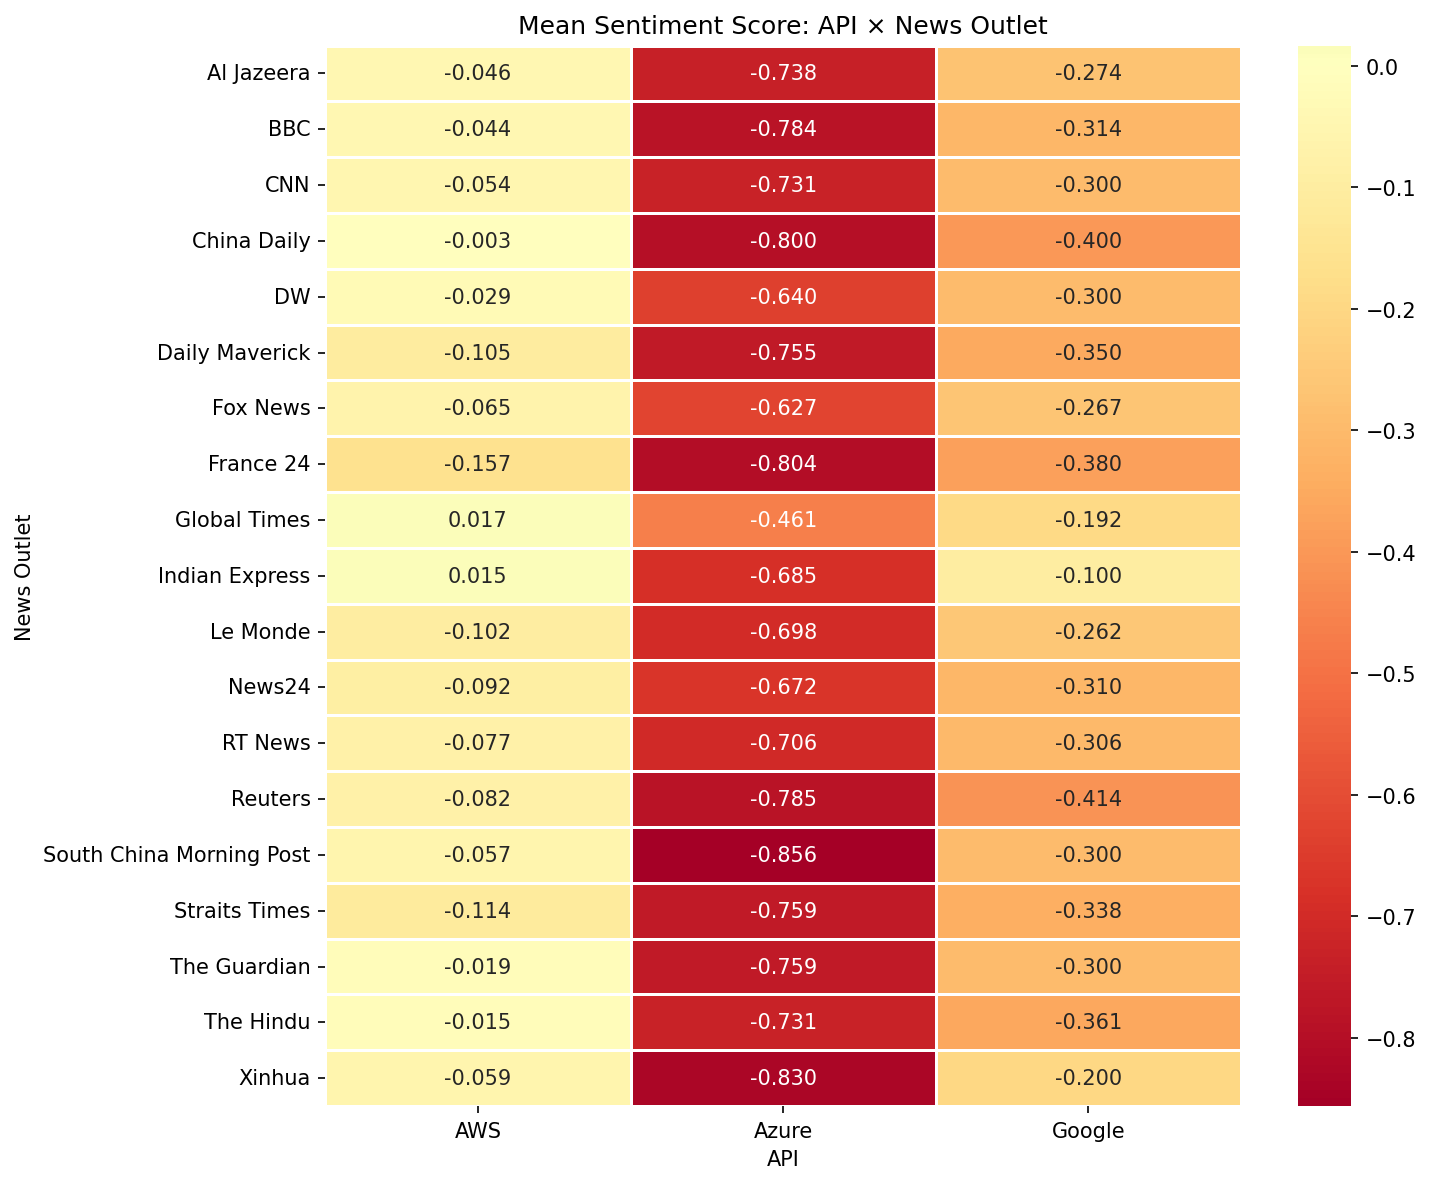

✓ Saved: heatmap_api_outlet_sentiment.png


In [38]:
# 1. HEATMAP: Mean sentiment per API × Outlet
# shows whether certain outlets are systematically scored differently
# by different APIs.

pivot_api_outlet = df_sent.pivot_table(
    index='outlet',
    columns='api',
    values='net_sentiment',
    aggfunc='mean'
).sort_index()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot_api_outlet,
    annot=True, fmt='.3f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Mean Sentiment Score: API × News Outlet')
ax.set_ylabel('News Outlet')
ax.set_xlabel('API')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'heatmap_api_outlet_sentiment.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: heatmap_api_outlet_sentiment.png')

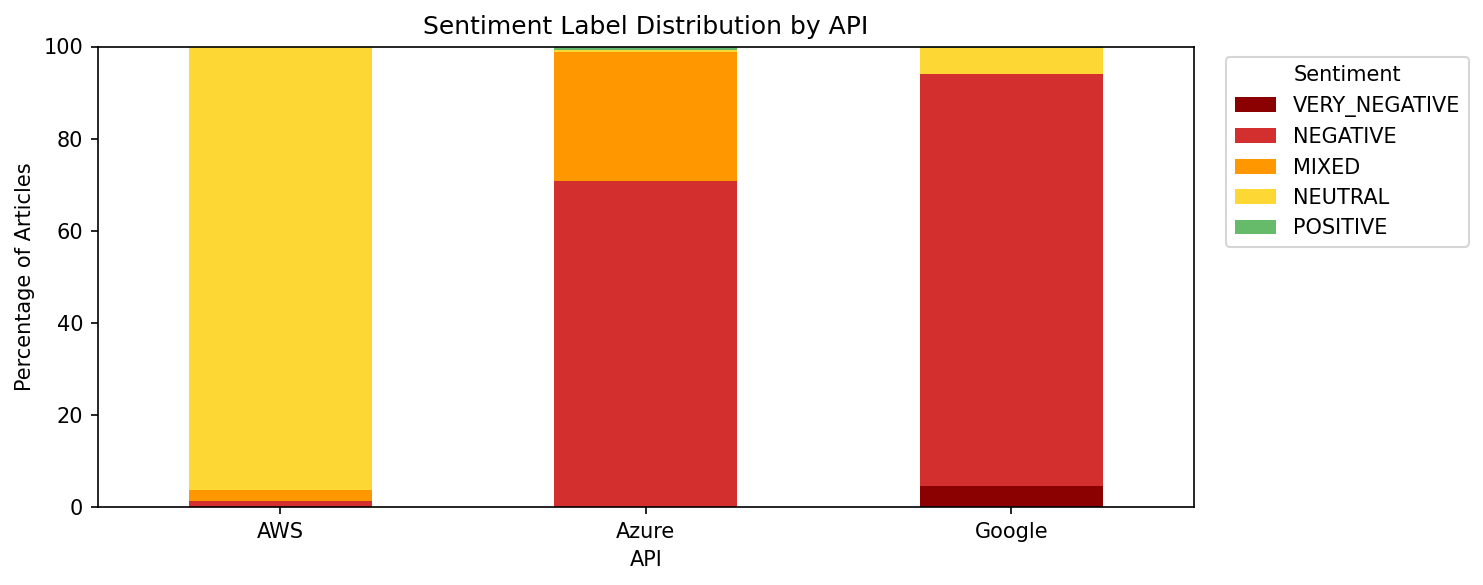

✓ Saved: barplot_api_label_distribution.png


In [39]:
# 2. HEATMAP: Sentiment label distribution per API
# shows how each API distributes its labels (are they mostly neutral?
# mostly negative?)

label_dist = df_sent.groupby(['api', 'sentiment_label']).size().unstack(fill_value=0)
# normalise to percentages
label_pct = label_dist.div(label_dist.sum(axis=1), axis=0) * 100

# explicit color mapping - semantically meaningful
LABEL_COLORS = {
    'VERY_NEGATIVE': '#8B0000',   # dark red
    'NEGATIVE':      '#D32F2F',   # red
    'MIXED':         '#FF9800',   # orange
    'NEUTRAL':       '#FDD835',   # yellow
    'POSITIVE':      '#66BB6A',   # green
    'VERY_POSITIVE': '#2E7D32',   # dark green
}

# only include colors for labels that actually appear in the data
ordered_labels = [l for l in LABEL_COLORS if l in label_pct.columns]
label_pct = label_pct[ordered_labels]
colors = [LABEL_COLORS[l] for l in ordered_labels]

fig, ax = plt.subplots(figsize=(10, 4))
label_pct.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Sentiment Label Distribution by API')
ax.set_ylabel('Percentage of Articles')
ax.set_xlabel('API')
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'barplot_api_label_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: barplot_api_label_distribution.png')

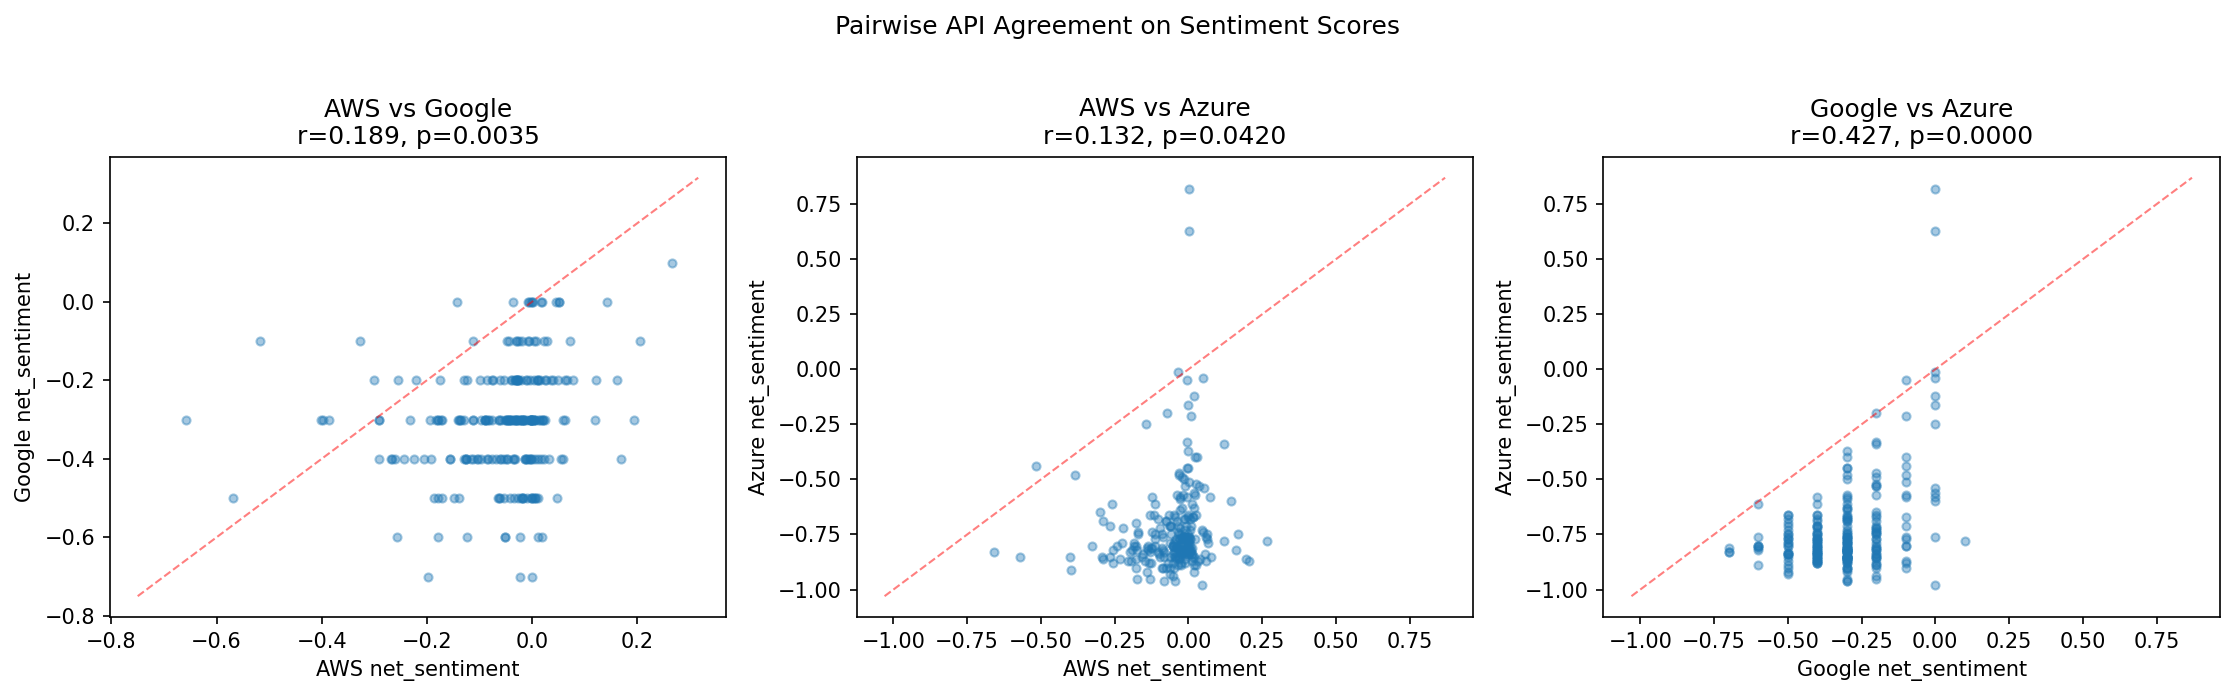

✓ Saved: scatter_pairwise_api_agreement.png


In [40]:
# 3. SCATTER: Pairwise API agreement
# each point is an article; axes are two APIs' scores.
# perfect agreement = diagonal line.

api_pairs = [('AWS', 'Google'), ('AWS', 'Azure'), ('Google', 'Azure')]

pivot_raw = df_sent.pivot_table(
    index='article_id', columns='api', values='net_sentiment'
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (api_a, api_b) in zip(axes, api_pairs):
    if api_a in pivot_raw.columns and api_b in pivot_raw.columns:
        data = pivot_raw[[api_a, api_b]].dropna()
        ax.scatter(data[api_a], data[api_b], alpha=0.4, s=15)

        # diagonal reference line
        lims = [min(data[api_a].min(), data[api_b].min()) - 0.05,
                max(data[api_a].max(), data[api_b].max()) + 0.05]
        ax.plot(lims, lims, 'r--', alpha=0.5, linewidth=1)

        # correlation
        r, p = stats.pearsonr(data[api_a], data[api_b])
        ax.set_title(f'{api_a} vs {api_b}\nr={r:.3f}, p={p:.4f}')
        ax.set_xlabel(f'{api_a} net_sentiment')
        ax.set_ylabel(f'{api_b} net_sentiment')

plt.suptitle('Pairwise API Agreement on Sentiment Scores', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'scatter_pairwise_api_agreement.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: scatter_pairwise_api_agreement.png')

## Per-Outlet Sentiment Distributions

For each news outlet, is the sentiment distribution always skewed? If an outlet's articles consistently get negative scores across all APIs, that may reflect the outlet's actual tone rather than API bias.

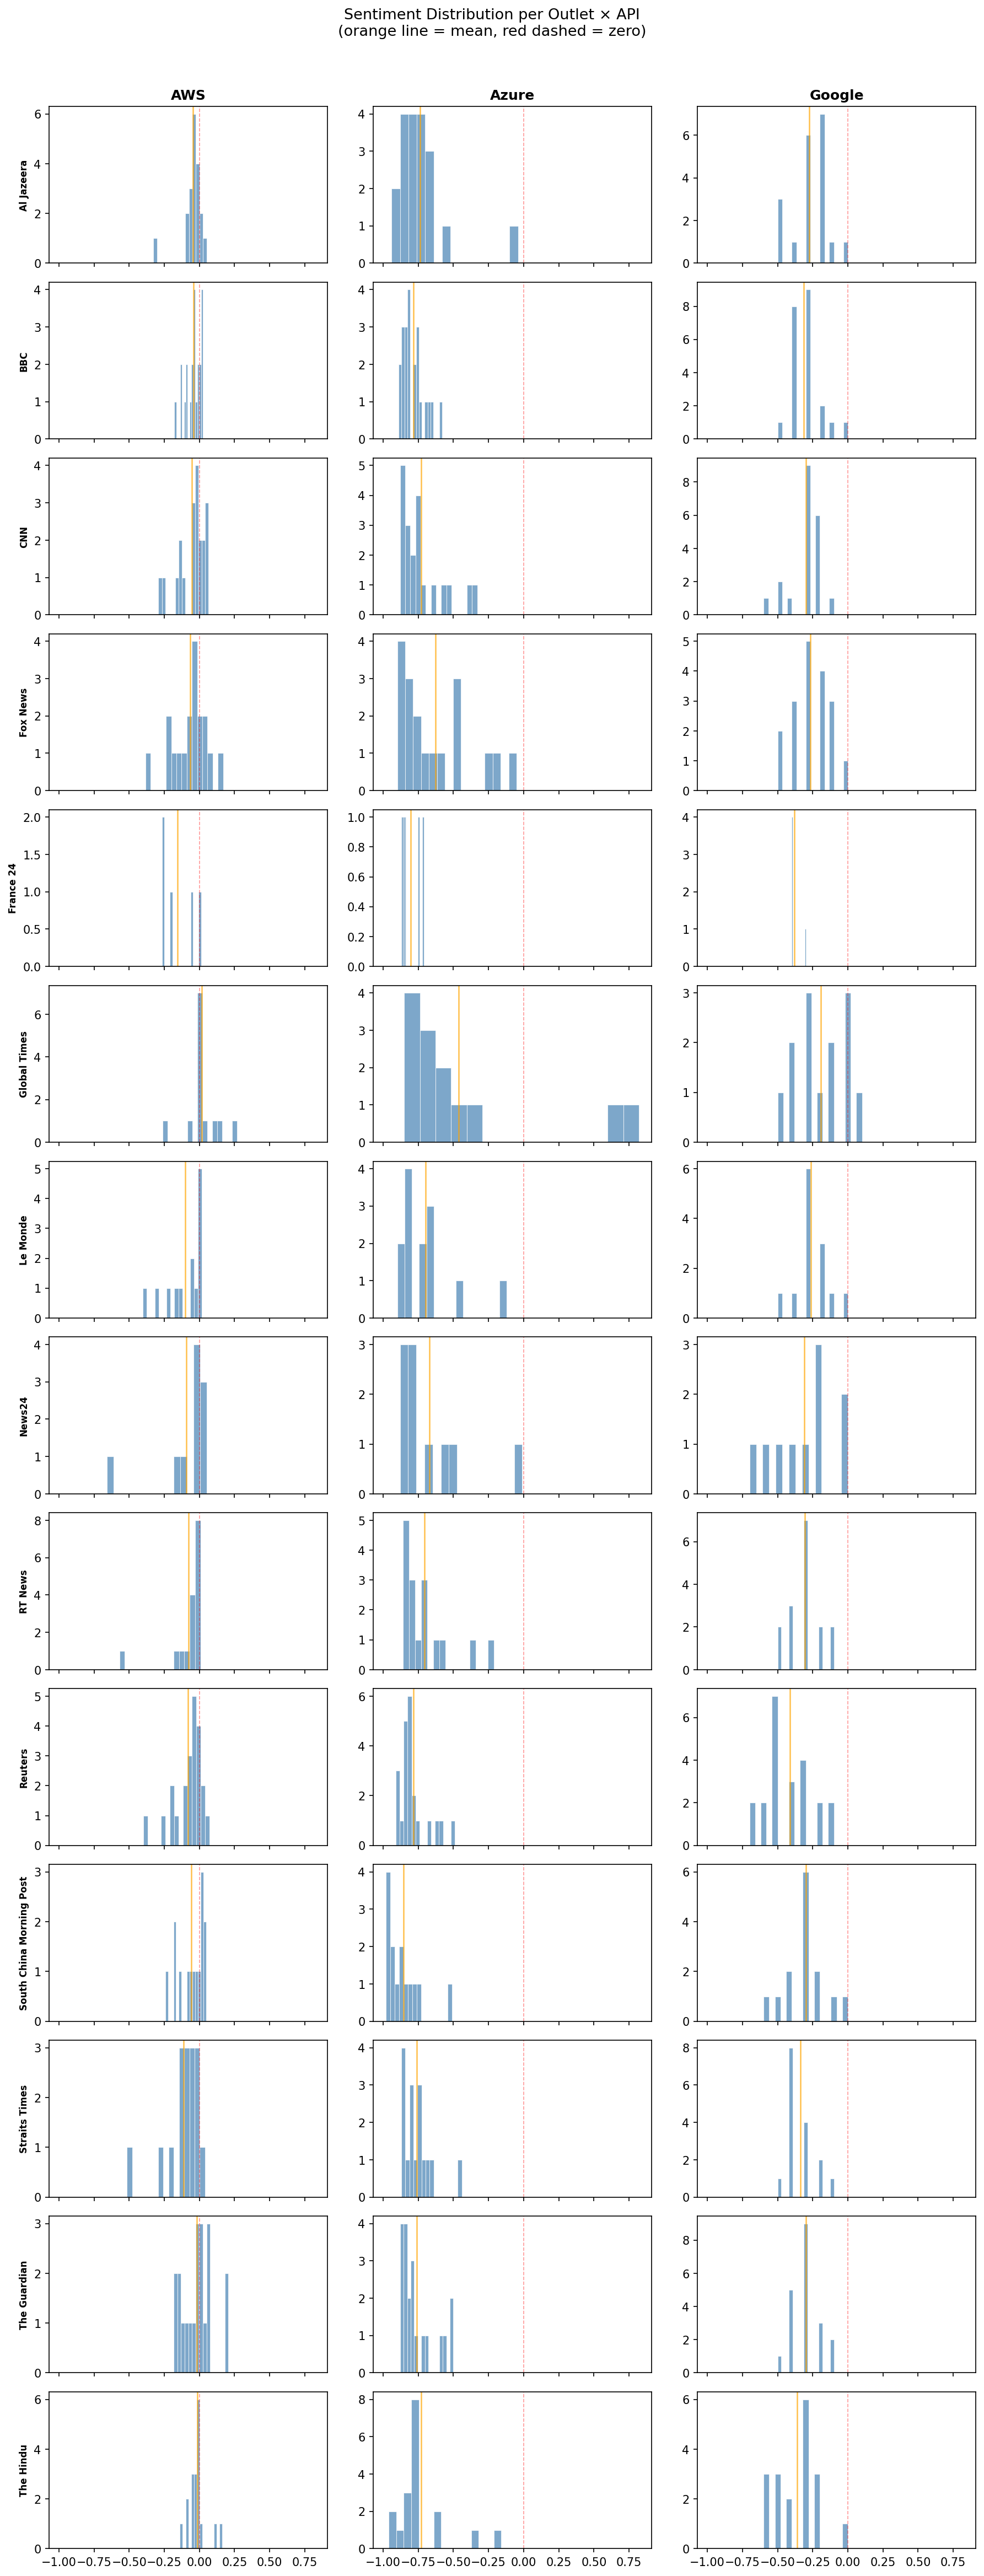

✓ Saved: histograms_outlet_api_sentiment.png


In [41]:
# HISTOGRAM: Sentiment distribution per outlet, per API
# each row = one outlet, each column = one API

apis = sorted(df_sent['api'].unique())
# only plot outlets with enough articles for a meaningful distribution
outlet_counts = df_articles['outlet'].value_counts()
major_outlets = outlet_counts[outlet_counts >= 5].index.tolist()
major_outlets = sorted(major_outlets)

n_outlets = len(major_outlets)
n_apis = len(apis)

fig, axes = plt.subplots(n_outlets, n_apis, figsize=(4 * n_apis, 2.2 * n_outlets),
                         sharex=True, sharey=False)

for i, outlet in enumerate(major_outlets):
    for j, api in enumerate(apis):
        ax = axes[i, j] if n_outlets > 1 else axes[j]
        subset = df_sent[(df_sent['outlet'] == outlet) & (df_sent['api'] == api)]

        if len(subset) > 0:
            ax.hist(subset['net_sentiment'], bins=15, alpha=0.7,
                    color='steelblue', edgecolor='white', linewidth=0.5)
            ax.axvline(x=0, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
            ax.axvline(x=subset['net_sentiment'].mean(), color='orange',
                       linestyle='-', alpha=0.7, linewidth=1.2)

        if i == 0:
            ax.set_title(api, fontweight='bold')
        if j == 0:
            ax.set_ylabel(outlet, fontsize=8, fontweight='bold')

plt.suptitle('Sentiment Distribution per Outlet × API\n(orange line = mean, red dashed = zero)',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'histograms_outlet_api_sentiment.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: histograms_outlet_api_sentiment.png')

In [42]:
# SUMMARY TABLE: Per-outlet sentiment statistics
# are some outlets always polarised, or is it API-dependent?

outlet_api_stats = df_sent.groupby(['outlet', 'api'])['net_sentiment'].agg(
    ['mean', 'std', 'median', 'count']
).round(4)

print('SENTIMENT STATISTICS: Outlet × API')
print('=' * 65)
print(outlet_api_stats.to_string())

# save
outlet_api_stats.to_csv(os.path.join(OUTPUT_DIR, 'table_outlet_api_stats.csv'))
print(f'\n✓ table_outlet_api_stats.csv saved')

SENTIMENT STATISTICS: Outlet × API
                                   mean     std  median  count
outlet                   api                                  
Al Jazeera               AWS    -0.0462  0.0774 -0.0299     19
                         Azure  -0.7379  0.1912 -0.7700     19
                         Google -0.2737  0.1327 -0.3000     19
BBC                      AWS    -0.0440  0.0556 -0.0370     22
                         Azure  -0.7841  0.0787 -0.8100     22
                         Google -0.3136  0.1125 -0.3000     22
CNN                      AWS    -0.0544  0.0998 -0.0236     20
                         Azure  -0.7310  0.1568 -0.7750     20
                         Google -0.3000  0.1214 -0.3000     20
China Daily              AWS    -0.0026     NaN -0.0026      1
                         Azure  -0.8000     NaN -0.8000      1
                         Google -0.4000     NaN -0.4000      1
DW                       AWS    -0.0291     NaN -0.0291      1
                    

## Outlet × Topic Polarity

For each outlet, does polarity vary by topic? Maybe an outlet is neutral on environment but negative on immigration. This helps separate outlet-level effects from topic-level effects.

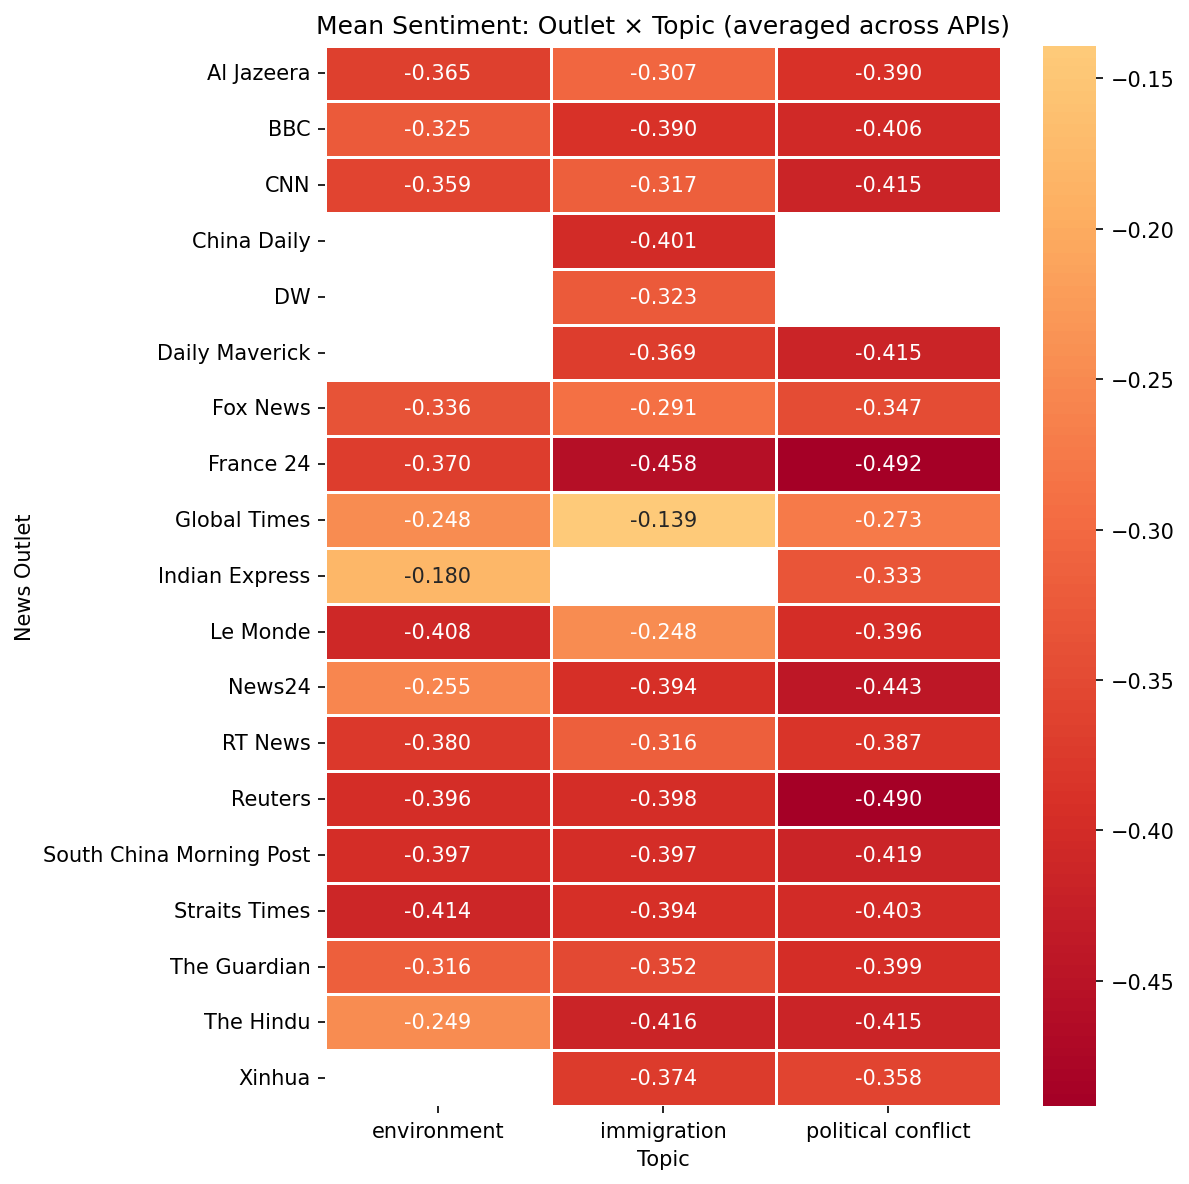

✓ Saved: heatmap_outlet_topic_sentiment.png


In [43]:
# HEATMAP: Mean sentiment per Outlet × Topic (averaged across APIs)

pivot_outlet_topic = df_sent.pivot_table(
    index='outlet',
    columns='topic',
    values='net_sentiment',
    aggfunc='mean'
).sort_index()

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    pivot_outlet_topic,
    annot=True, fmt='.3f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Mean Sentiment: Outlet × Topic (averaged across APIs)')
ax.set_ylabel('News Outlet')
ax.set_xlabel('Topic')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'heatmap_outlet_topic_sentiment.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: heatmap_outlet_topic_sentiment.png')

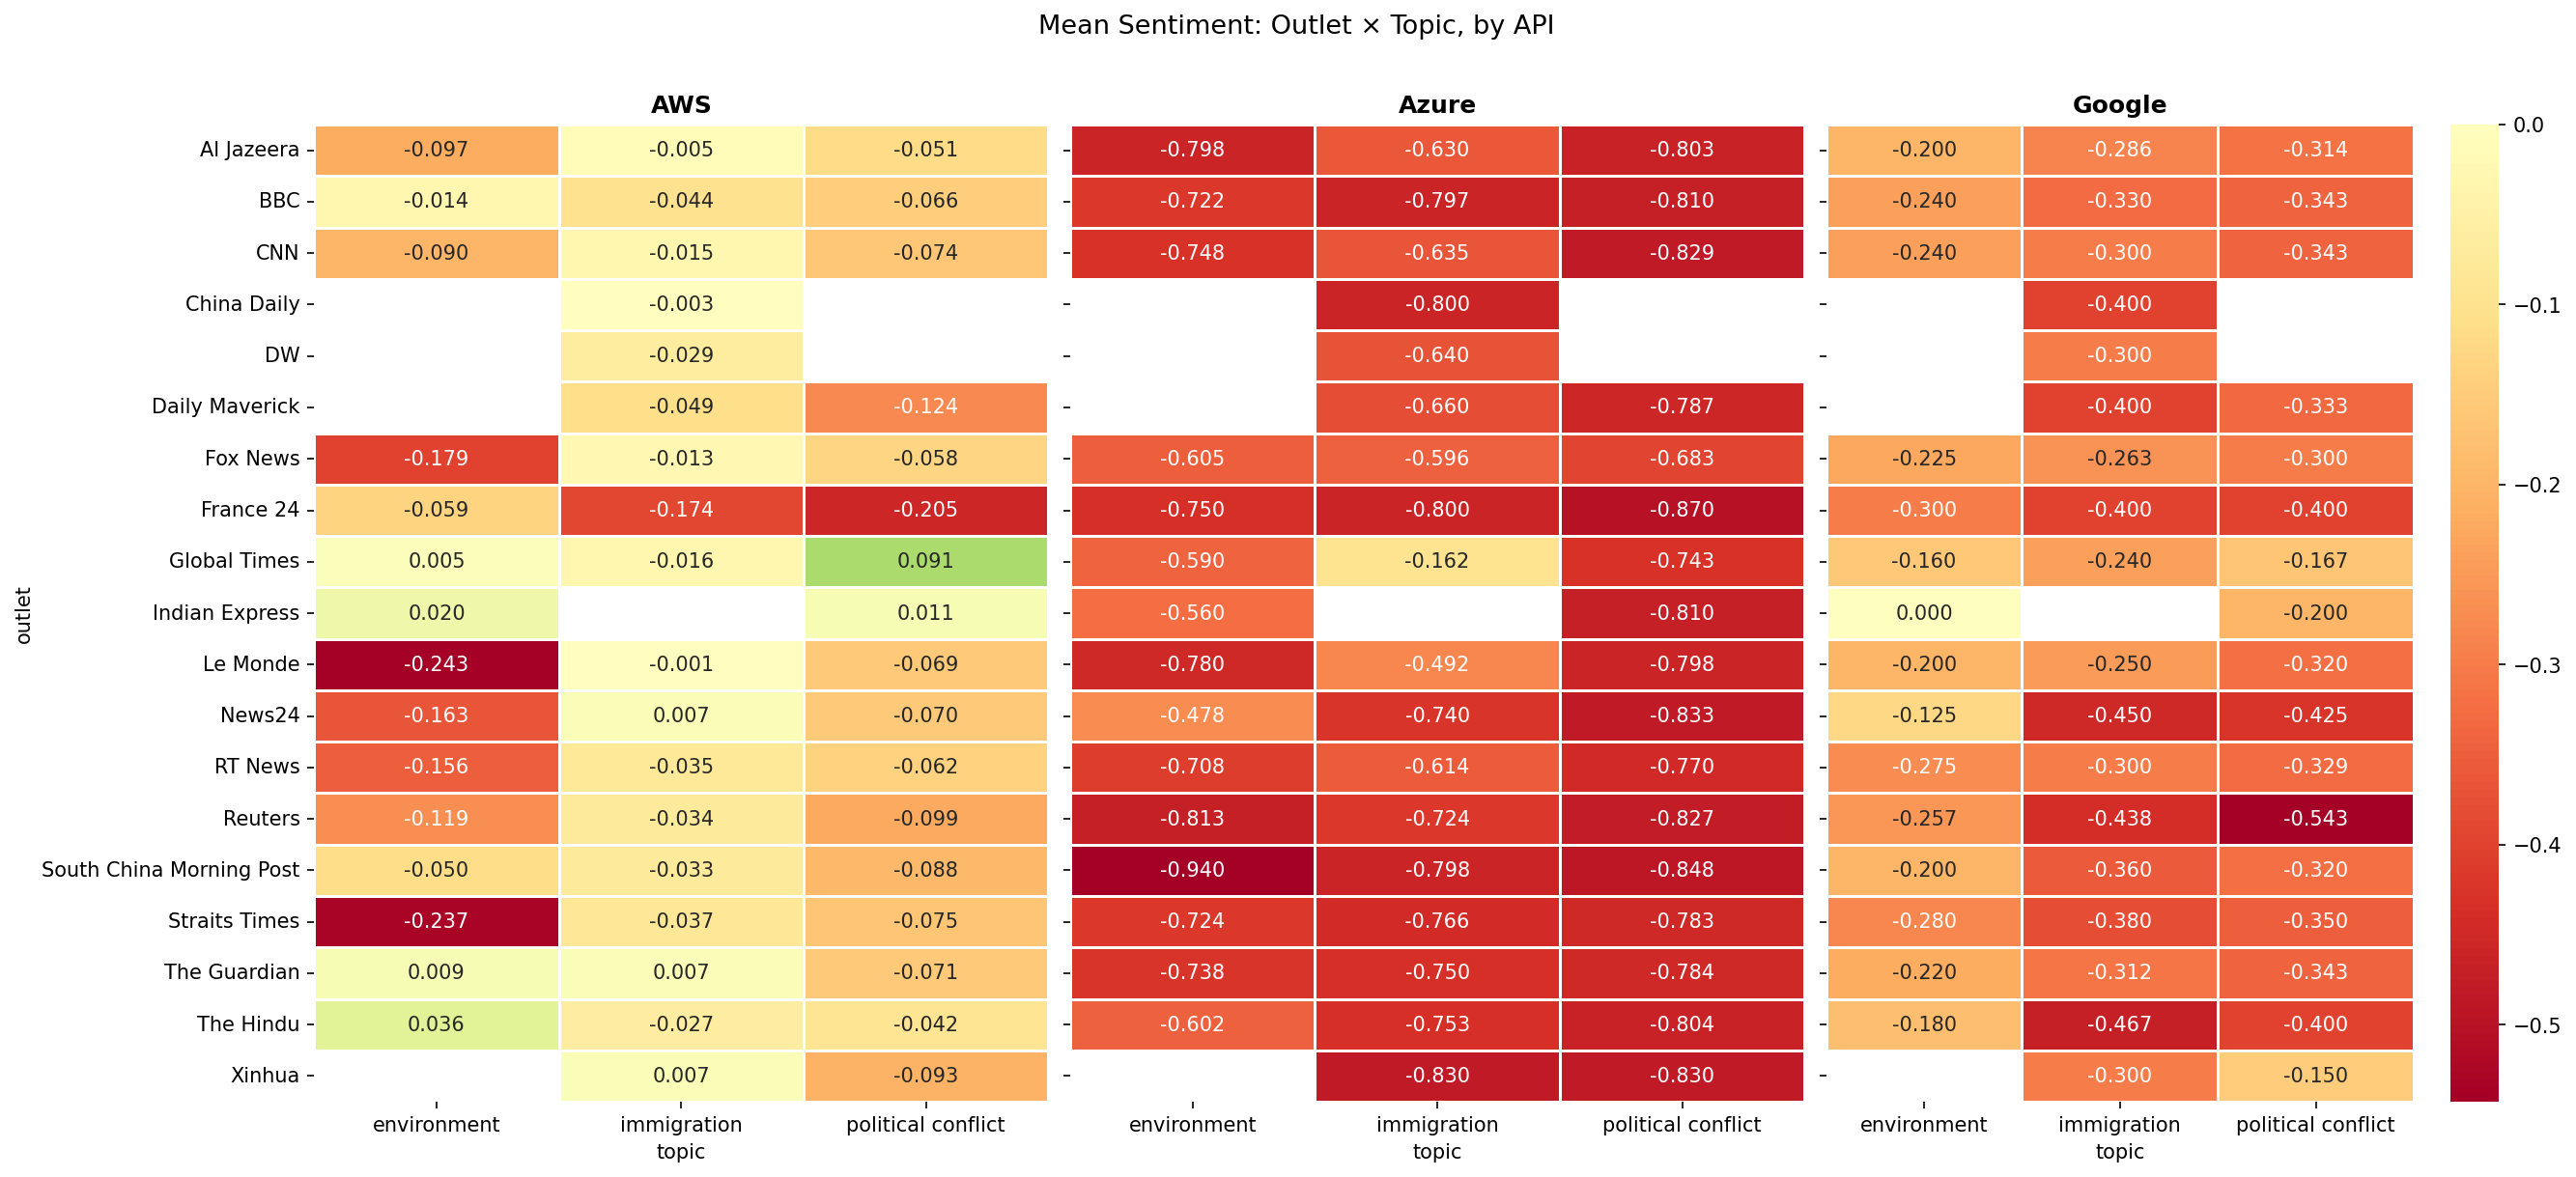

✓ Saved: heatmap_outlet_topic_per_api.png


In [44]:
# HEATMAP: Per API - Outlet × Topic (3 separate heatmaps)

fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

for ax, api in zip(axes, apis):
    api_data = df_sent[df_sent['api'] == api]
    pivot = api_data.pivot_table(
        index='outlet', columns='topic',
        values='net_sentiment', aggfunc='mean'
    ).sort_index()

    sns.heatmap(
        pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
        linewidths=0.5, ax=ax,
        cbar=ax == axes[-1]  # Only show colorbar on last subplot
    )
    ax.set_title(f'{api}', fontweight='bold')
    if ax != axes[0]:
        ax.set_ylabel('')

plt.suptitle('Mean Sentiment: Outlet × Topic, by API', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'heatmap_outlet_topic_per_api.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: heatmap_outlet_topic_per_api.png')

## Country/Region Bias Analysis

Does the country of origin of the outlet predict sentiment scores? Do APIs treat Western and Non-Western sources differently?

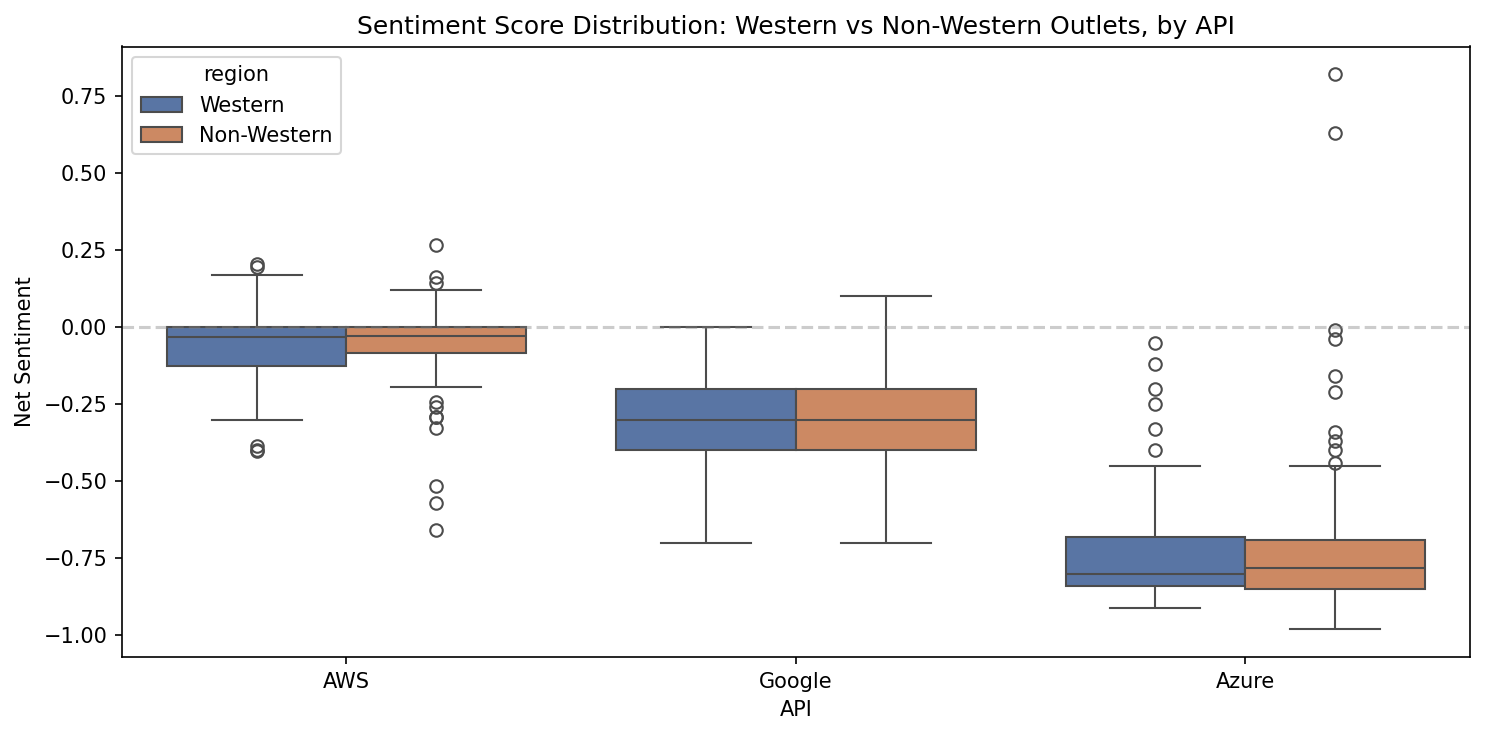

✓ Saved: boxplot_region_api_sentiment.png


In [45]:
# BOXPLOT: Sentiment by Region × API

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_sent, x='api', y='net_sentiment', hue='region',
    palette={'Western': '#4C72B0', 'Non-Western': '#DD8452'},
    ax=ax
)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_title('Sentiment Score Distribution: Western vs Non-Western Outlets, by API')
ax.set_ylabel('Net Sentiment')
ax.set_xlabel('API')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'boxplot_region_api_sentiment.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: boxplot_region_api_sentiment.png')

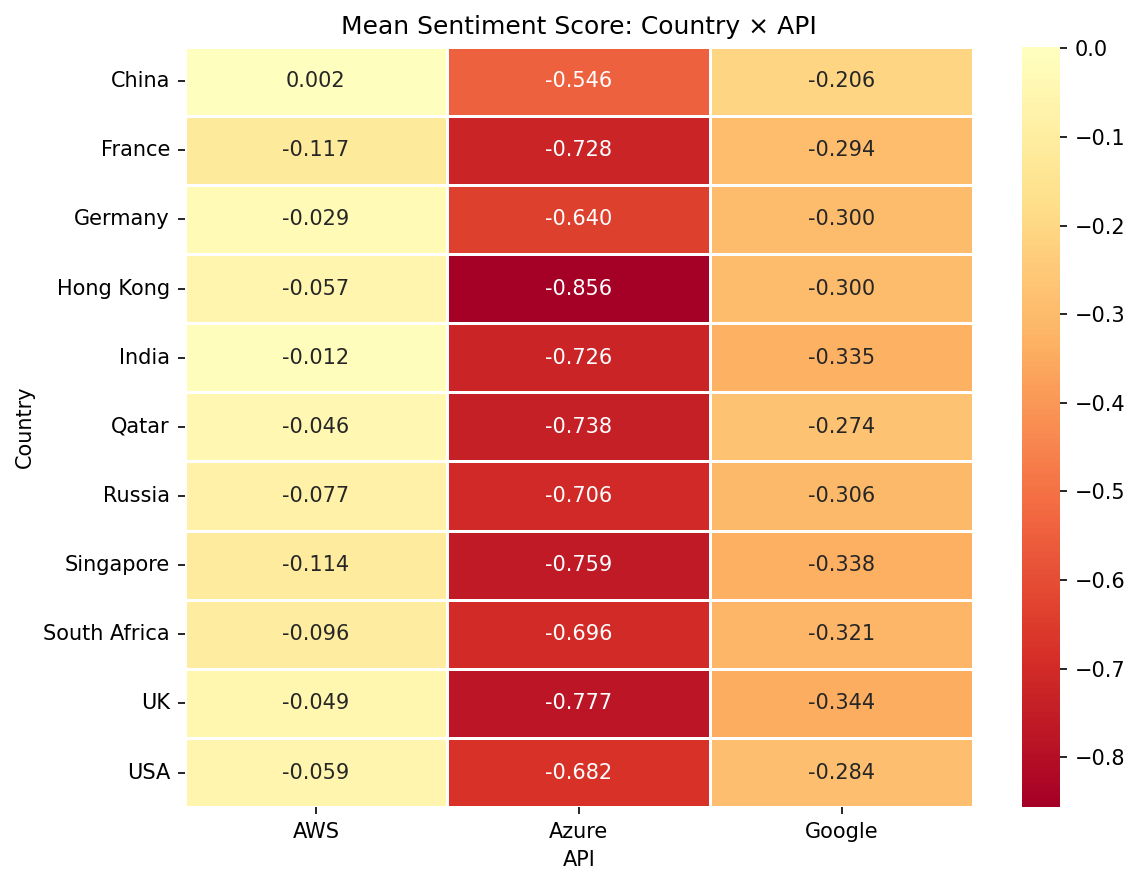

✓ Saved: heatmap_country_api_sentiment.png


In [46]:
# HEATMAP: Mean sentiment by Country × API

pivot_country_api = df_sent.pivot_table(
    index='country', columns='api',
    values='net_sentiment', aggfunc='mean'
).sort_index()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot_country_api,
    annot=True, fmt='.3f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Mean Sentiment Score: Country × API')
ax.set_ylabel('Country')
ax.set_xlabel('API')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'heatmap_country_api_sentiment.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: heatmap_country_api_sentiment.png')

In [47]:
# STATISTICAL TEST: Western vs Non-Western per API

def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled = np.sqrt(((n1-1)*g1.var() + (n2-1)*g2.var()) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled if pooled > 0 else 0.0

print('WESTERN vs NON-WESTERN: Statistical Tests')
print('=' * 60)

region_test_rows = []
for api in apis:
    api_data = df_sent[df_sent['api'] == api]
    w = api_data[api_data['region'] == 'Western']['net_sentiment'].dropna()
    nw = api_data[api_data['region'] == 'Non-Western']['net_sentiment'].dropna()

    if len(w) >= 2 and len(nw) >= 2:
        t, p = stats.ttest_ind(w, nw)
        d = cohens_d(w, nw)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        effect = 'large' if abs(d) >= 0.8 else 'medium' if abs(d) >= 0.5 else 'small' if abs(d) >= 0.2 else 'negligible'

        print(f'\n{api}:')
        print(f'  Western:     mean={w.mean():.4f}, std={w.std():.4f}, n={len(w)}')
        print(f'  Non-Western: mean={nw.mean():.4f}, std={nw.std():.4f}, n={len(nw)}')
        print(f'  t={t:.4f}, p={p:.4f} {sig}, Cohen\'s d={d:.4f} ({effect})')

        region_test_rows.append({
            'api': api, 'western_mean': round(w.mean(), 4),
            'non_western_mean': round(nw.mean(), 4),
            't_stat': round(t, 4), 'p_value': round(p, 4),
            'cohens_d': round(d, 4), 'effect_size': effect
        })

pd.DataFrame(region_test_rows).to_csv(
    os.path.join(OUTPUT_DIR, 'table_region_tests.csv'), index=False
)
print(f'\n✓ table_region_tests.csv saved')

WESTERN vs NON-WESTERN: Statistical Tests

AWS:
  Western:     mean=-0.0624, std=0.1086, n=121
  Non-Western: mean=-0.0541, std=0.1213, n=116
  t=-0.5516, p=0.5817 ns, Cohen's d=-0.0717 (negligible)

Azure:
  Western:     mean=-0.7384, std=0.1619, n=121
  Non-Western: mean=-0.7155, std=0.2590, n=116
  t=-0.8203, p=0.4129 ns, Cohen's d=-0.1066 (negligible)

Google:
  Western:     mean=-0.3174, std=0.1364, n=121
  Non-Western: mean=-0.2966, std=0.1577, n=116
  t=-1.0876, p=0.2779 ns, Cohen's d=-0.1413 (negligible)

✓ table_region_tests.csv saved


## Topic as a Confounder

Some topics are inherently negative (political conflict, environmental crises). Before attributing bias to outlets or countries, we need to account for the effect of topic on sentiment.

This cell computes **topic-adjusted sentiment** by subtracting each topic's baseline mean, so remaining differences are attributable to outlet, country, or API - not topic.

In [48]:
# TOPIC BASELINE: Average sentiment per topic × API

topic_baselines = df_sent.groupby(['api', 'topic'])['net_sentiment'].mean()

print('TOPIC BASELINES (mean sentiment per topic × API)')
print('=' * 55)
print(topic_baselines.unstack().round(4).to_string())
print()

# compute topic-adjusted sentiment:
# adjusted = raw score - topic baseline for that API
# positive adjusted = more positive than topic average
# negative adjusted = more negative than topic average

df_sent['topic_baseline'] = df_sent.apply(
    lambda r: topic_baselines.get((r['api'], r['topic']), 0), axis=1
)
df_sent['net_sentiment_topic_adjusted'] = df_sent['net_sentiment'] - df_sent['topic_baseline']

print('Topic-adjusted sentiment computed.')
print('Positive = more positive than topic average for that API.')
print('This separates topic effects from outlet/country effects.')

TOPIC BASELINES (mean sentiment per topic × API)
topic   environment  immigration  political conflict
api                                                 
AWS         -0.0934      -0.0257             -0.0657
Azure       -0.7133      -0.6707             -0.7962
Google      -0.2156      -0.3352             -0.3471

Topic-adjusted sentiment computed.
Positive = more positive than topic average for that API.
This separates topic effects from outlet/country effects.


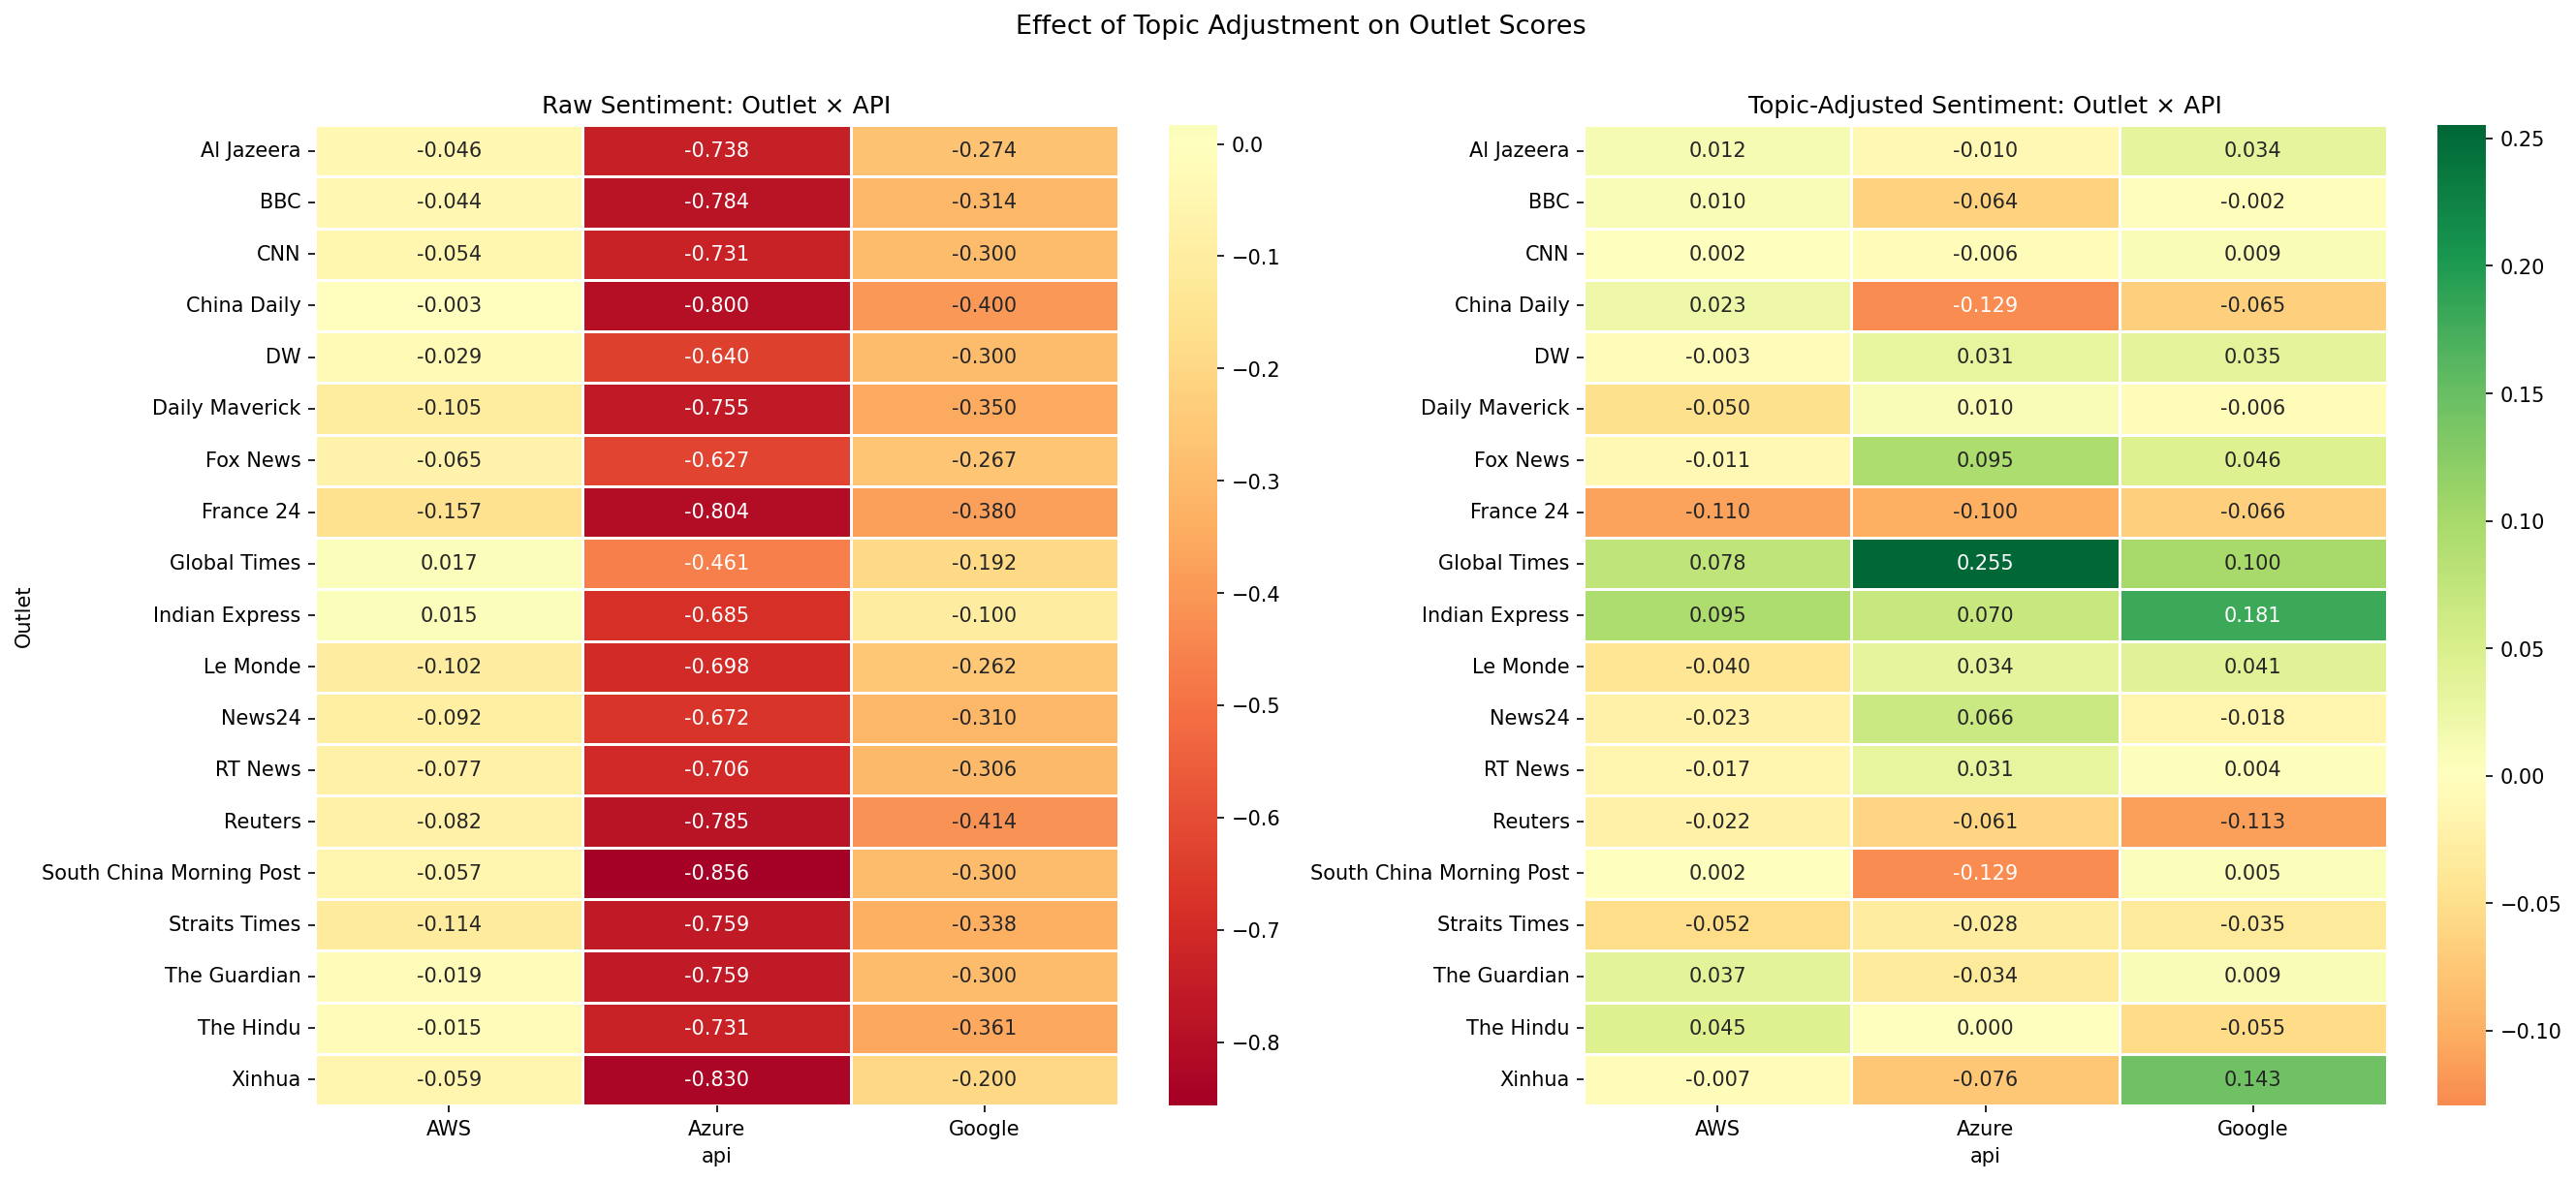

✓ Saved: heatmap_raw_vs_adjusted_outlet.png


In [49]:
# HEATMAP: Topic-adjusted sentiment by Outlet × API
# can see outlet effects with topic controlled for.

pivot_adjusted = df_sent.pivot_table(
    index='outlet', columns='api',
    values='net_sentiment_topic_adjusted',
    aggfunc='mean'
).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# raw
sns.heatmap(pivot_api_outlet, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Raw Sentiment: Outlet × API')
axes[0].set_ylabel('Outlet')

# topic-adjusted
sns.heatmap(pivot_adjusted, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Topic-Adjusted Sentiment: Outlet × API')
axes[1].set_ylabel('')

plt.suptitle('Effect of Topic Adjustment on Outlet Scores', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'heatmap_raw_vs_adjusted_outlet.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: heatmap_raw_vs_adjusted_outlet.png')

In [50]:
# RE-TEST: Western vs Non-Western AFTER topic adjustment
# if the regional difference disappears after adjustment, it was
# driven by topic distribution, not actual regional bias.

print('WESTERN vs NON-WESTERN: After Topic Adjustment')
print('=' * 60)

for api in apis:
    api_data = df_sent[df_sent['api'] == api]
    w = api_data[api_data['region'] == 'Western']['net_sentiment_topic_adjusted'].dropna()
    nw = api_data[api_data['region'] == 'Non-Western']['net_sentiment_topic_adjusted'].dropna()

    if len(w) >= 2 and len(nw) >= 2:
        t, p = stats.ttest_ind(w, nw)
        d = cohens_d(w, nw)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f'{api}: Western adj_mean={w.mean():.4f}, Non-Western adj_mean={nw.mean():.4f}')
        print(f'  t={t:.4f}, p={p:.4f} {sig}, d={d:.4f}')
        print()

WESTERN vs NON-WESTERN: After Topic Adjustment
AWS: Western adj_mean=-0.0061, Non-Western adj_mean=0.0064
  t=-0.8592, p=0.3911 ns, d=-0.1116

Azure: Western adj_mean=-0.0153, Non-Western adj_mean=0.0160
  t=-1.1607, p=0.2469 ns, d=-0.1508

Google: Western adj_mean=-0.0089, Non-Western adj_mean=0.0092
  t=-1.0229, p=0.3074 ns, d=-0.1329



## Decomposing Bias Sources (ANOVA)

Uses two-way ANOVA to estimate how much of the variance in sentiment scores is explained by each factor (API, outlet, topic, region). This answers the core question: **where is the bias coming from?**

In [51]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# FACTORIAL ANOVA: What factors explain sentiment variance?
# factors: API, topic, outlet, region

# prepare data - ensure clean factor columns
anova_data = df_sent[['net_sentiment', 'api', 'topic', 'outlet', 'region']].dropna().copy()

# patsy cannot interpret pandas StringDtype - cast factor columns to plain object
for col in ['api', 'topic', 'outlet', 'region']:
    anova_data[col] = anova_data[col].astype('object')

# ensure response is plain float (not nullable Float64)
anova_data['net_sentiment'] = pd.to_numeric(anova_data['net_sentiment'], errors='coerce')
anova_data = anova_data.dropna(subset=['net_sentiment'])

# ── Model 1: Main effects only ──────────────────────────────────────
print('ANOVA MODEL 1: Main Effects')
print('=' * 65)
print('net_sentiment ~ C(api) + C(topic) + C(region)\n')

model1 = ols('net_sentiment ~ C(api) + C(topic) + C(region)', data=anova_data).fit()
anova1 = sm.stats.anova_lm(model1, typ=2)

# add percentage of variance explained (eta-squared)
anova1['eta_squared'] = anova1['sum_sq'] / anova1['sum_sq'].sum()
anova1['eta_squared_pct'] = (anova1['eta_squared'] * 100).round(2)

print(anova1[['sum_sq', 'df', 'F', 'PR(>F)', 'eta_squared_pct']].round(4).to_string())
print(f'\nModel R² = {model1.rsquared:.4f}')
print(f'This means {model1.rsquared*100:.1f}% of sentiment variance is explained by API + topic + region.')

# ── Model 2: Add outlet (nested within region) ─────────────────────
print(f'\n\nANOVA MODEL 2: With Outlet')
print('=' * 65)
print('net_sentiment ~ C(api) + C(topic) + C(outlet)\n')

model2 = ols('net_sentiment ~ C(api) + C(topic) + C(outlet)', data=anova_data).fit()
anova2 = sm.stats.anova_lm(model2, typ=2)
anova2['eta_squared'] = anova2['sum_sq'] / anova2['sum_sq'].sum()
anova2['eta_squared_pct'] = (anova2['eta_squared'] * 100).round(2)

print(anova2[['sum_sq', 'df', 'F', 'PR(>F)', 'eta_squared_pct']].round(4).to_string())
print(f'\nModel R² = {model2.rsquared:.4f}')
print(f'Improvement over Model 1: +{(model2.rsquared - model1.rsquared)*100:.1f}% variance explained by adding outlet.')

ANOVA MODEL 1: Main Effects
net_sentiment ~ C(api) + C(topic) + C(region)

            sum_sq     df          F  PR(>F)  eta_squared_pct
C(api)     54.1763    2.0  1035.5392  0.0000            73.89
C(topic)    0.6213    2.0    11.8758  0.0000             0.85
C(region)   0.0762    1.0     2.9120  0.0884             0.10
Residual   18.4417  705.0        NaN     NaN            25.15

Model R² = 0.7484
This means 74.8% of sentiment variance is explained by API + topic + region.


ANOVA MODEL 2: With Outlet
net_sentiment ~ C(api) + C(topic) + C(outlet)

            sum_sq     df          F  PR(>F)  eta_squared_pct
C(api)     54.1763    2.0  1101.7297     0.0            73.96
C(topic)    0.5548    2.0    11.2814     0.0             0.76
C(outlet)   1.6021   18.0     3.6201     0.0             2.19
Residual   16.9158  688.0        NaN     NaN            23.09

Model R² = 0.7692
Improvement over Model 1: +2.1% variance explained by adding outlet.


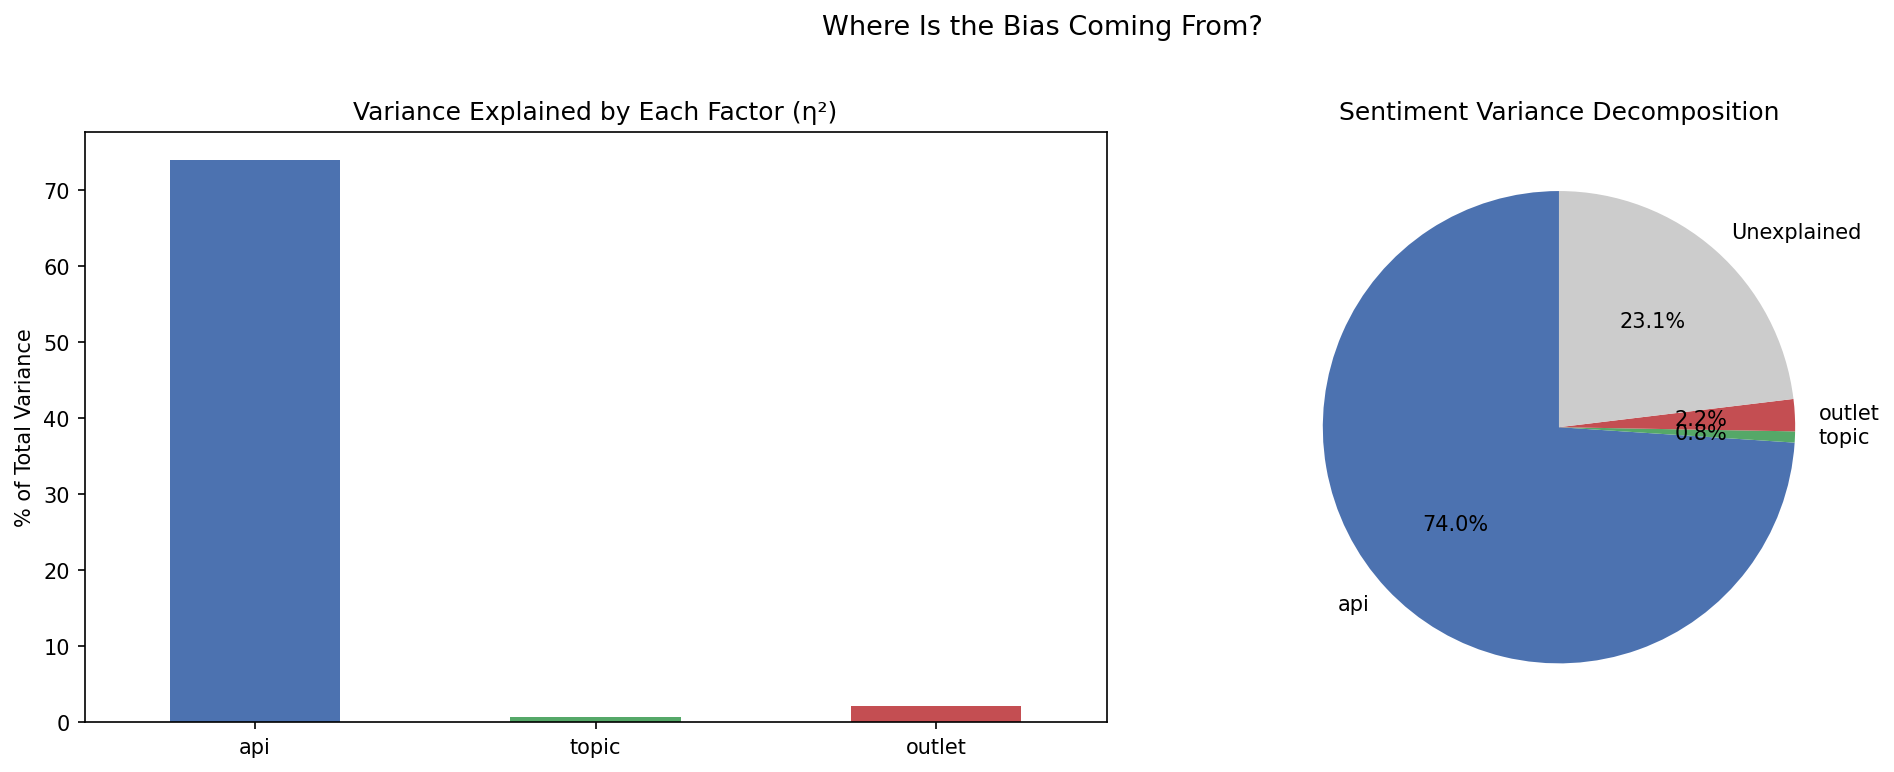

✓ Saved: chart_variance_decomposition.png


In [52]:
# VISUALISE: Variance decomposition (pie/bar chart)

# use Model 2 (with outlet) for the decomposition
decomp = anova2[['eta_squared_pct']].copy()
decomp = decomp[decomp.index != 'Residual']
decomp.index = [idx.replace('C(', '').replace(')', '') for idx in decomp.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
decomp['eta_squared_pct'].plot(kind='bar', ax=axes[0], color=colors[:len(decomp)])
axes[0].set_title('Variance Explained by Each Factor (η²)')
axes[0].set_ylabel('% of Total Variance')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# add residual for pie chart
residual_pct = anova2.loc['Residual', 'eta_squared_pct']
pie_data = decomp['eta_squared_pct'].tolist() + [residual_pct]
pie_labels = decomp.index.tolist() + ['Unexplained']
pie_colors = colors[:len(decomp)] + ['#CCCCCC']

axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', colors=pie_colors, startangle=90)
axes[1].set_title('Sentiment Variance Decomposition')

plt.suptitle('Where Is the Bias Coming From?', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'chart_variance_decomposition.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: chart_variance_decomposition.png')

## IPSV by Outlet, Country, and Topic

Do the APIs disagree *more* on articles from specific outlets, countries, or topics?

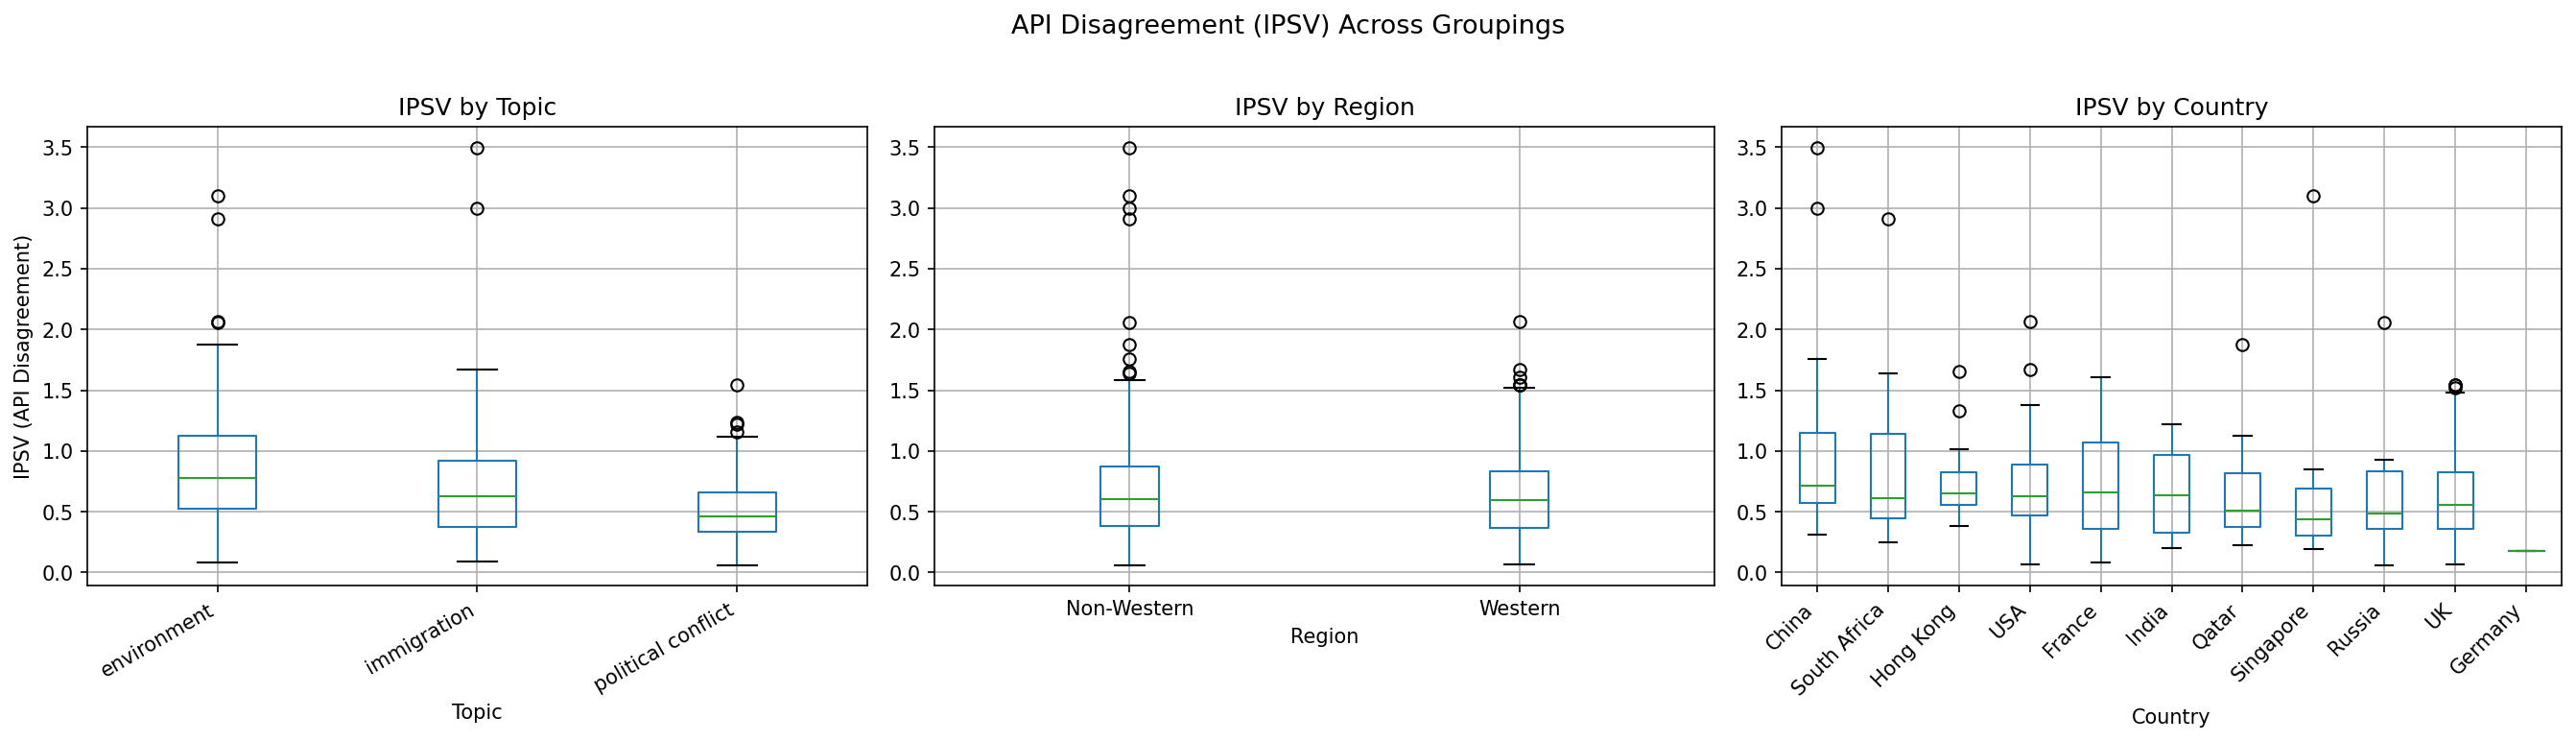

✓ Saved: boxplot_ipsv_by_grouping.png


In [53]:
# IPSV ANALYSIS by outlet, country, and region

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# by topic
df_ipsv.boxplot(column='IPSV', by='topic', ax=axes[0])
axes[0].set_title('IPSV by Topic')
axes[0].set_xlabel('Topic')
axes[0].set_ylabel('IPSV (API Disagreement)')
plt.sca(axes[0])
plt.xticks(rotation=30, ha='right')

# by region
df_ipsv.boxplot(column='IPSV', by='region', ax=axes[1])
axes[1].set_title('IPSV by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('')

# by country
country_order = df_ipsv.groupby('country')['IPSV'].mean().sort_values(ascending=False).index
df_ipsv_sorted = df_ipsv.copy()
df_ipsv_sorted['country'] = pd.Categorical(df_ipsv_sorted['country'], categories=country_order, ordered=True)
df_ipsv_sorted.boxplot(column='IPSV', by='country', ax=axes[2])
axes[2].set_title('IPSV by Country')
axes[2].set_xlabel('Country')
axes[2].set_ylabel('')
plt.sca(axes[2])
plt.xticks(rotation=45, ha='right')

plt.suptitle('API Disagreement (IPSV) Across Groupings', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'boxplot_ipsv_by_grouping.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: boxplot_ipsv_by_grouping.png')

In [54]:
# IPSV ANOVA - TWO MODELS
# model A (publisher decomposition): IPSV ~ topic + region + outlet
# answers "do publishers, regions, or topics drive cross-API disagreement?"
# model B (framing decomposition): IPSV ~ topic + frame nested in topic
# answers the methodology's framing question. A fully crossed topic×frame
# design is impossible because frame inventories differ by topic
# (immigration: humanitarian/security/neutral; environment: concern/
# skeptical/neutral; political conflict: people-centric/state-centric/
# neutral/sympathetic). The nested model `frame within topic` is the
# correct factorial alternative for this corpus.
# both tables are saved; the methodology's variance-attribution claim is
# read off Model B.

ipsv_anova_data = df_ipsv[['IPSV', 'topic', 'frame', 'outlet', 'region']].dropna().copy()

# patsy needs plain object dtype
for col in ['topic', 'frame', 'outlet', 'region']:
    ipsv_anova_data[col] = ipsv_anova_data[col].astype('object')
ipsv_anova_data['IPSV'] = pd.to_numeric(ipsv_anova_data['IPSV'], errors='coerce')
ipsv_anova_data = ipsv_anova_data.dropna(subset=['IPSV'])

# ── Model A: publisher decomposition (kept from previous version) ────
print('ANOVA MODEL A: Publisher Decomposition')
print('=' * 65)
print('IPSV ~ C(topic) + C(region) + C(outlet)\n')

model_ipsv_a = ols('IPSV ~ C(topic) + C(region) + C(outlet)', data=ipsv_anova_data).fit()
anova_a = sm.stats.anova_lm(model_ipsv_a, typ=2)
anova_a['eta_squared_pct'] = (anova_a['sum_sq'] / anova_a['sum_sq'].sum() * 100).round(2)
print(anova_a[['sum_sq', 'df', 'F', 'PR(>F)', 'eta_squared_pct']].round(4).to_string())
print(f'\nModel R² = {model_ipsv_a.rsquared:.4f}')

anova_a.to_csv(os.path.join(OUTPUT_DIR, 'table_ipsv_anova.csv'))
print(f'✓ table_ipsv_anova.csv saved (Model A: topic + region + outlet)')

# ── Model B: framing decomposition (topic × frame, frame nested) ─────
print('\n\nANOVA MODEL B: Framing Decomposition (nested)')
print('=' * 65)
print('IPSV ~ C(topic) + C(frame):C(topic)')
print('(frame nested in topic; frame inventories differ per topic so a')
print(' fully crossed design is undefined)\n')

model_ipsv_b = ols('IPSV ~ C(topic) + C(frame):C(topic)', data=ipsv_anova_data).fit()
anova_b = sm.stats.anova_lm(model_ipsv_b, typ=2)
anova_b['eta_squared_pct'] = (anova_b['sum_sq'] / anova_b['sum_sq'].sum() * 100).round(2)
print(anova_b[['sum_sq', 'df', 'F', 'PR(>F)', 'eta_squared_pct']].round(4).to_string())
print(f'\nModel R² = {model_ipsv_b.rsquared:.4f}')

anova_b.to_csv(os.path.join(OUTPUT_DIR, 'table_ipsv_anova_framing.csv'))
print(f'✓ table_ipsv_anova_framing.csv saved (Model B: topic + frame|topic)')

# ── Compact summary for the thesis ───────────────────────────────────
print('\n' + '=' * 65)
print('VARIANCE ATTRIBUTION SUMMARY (eta-squared %)')
print('=' * 65)
print(f'  Model A: topic = {anova_a.loc["C(topic)", "eta_squared_pct"]:.2f}%,  '
      f'region = {anova_a.loc["C(region)", "eta_squared_pct"]:.2f}%,  '
      f'outlet = {anova_a.loc["C(outlet)", "eta_squared_pct"]:.2f}%')
print(f'  Model B: topic = {anova_b.loc["C(topic)", "eta_squared_pct"]:.2f}%,  '
      f'frame|topic = {anova_b.loc["C(frame):C(topic)", "eta_squared_pct"]:.2f}%')


ANOVA MODEL A: Publisher Decomposition
IPSV ~ C(topic) + C(region) + C(outlet)

            sum_sq     df        F  PR(>F)  eta_squared_pct
C(topic)    5.4017    2.0  12.2172  0.0000             9.06
C(region)   0.0506    1.0   0.2289  0.6328             0.08
C(outlet)   6.4469   18.0   1.6202  0.0569            10.81
Residual   47.7506  216.0      NaN     NaN            80.05

Model R² = 0.2056
✓ table_ipsv_anova.csv saved (Model A: topic + region + outlet)


ANOVA MODEL B: Framing Decomposition (nested)
IPSV ~ C(topic) + C(frame):C(topic)
(frame nested in topic; frame inventories differ per topic so a
 fully crossed design is undefined)

                    sum_sq     df       F  PR(>F)  eta_squared_pct
C(topic)               NaN    2.0     NaN     NaN              NaN
C(frame):C(topic)  23.7922   18.0  6.0836     0.0            32.45
Residual           49.5381  228.0     NaN     NaN            67.55

Model R² = 0.1759
✓ table_ipsv_anova_framing.csv saved (Model B: topic + frame|topi

Kept 6 frames with n≥5 (excluded 3 articles)

IPSV by frame (ranked by mean):
                  mean     std  median  count
frame                                        
concern         0.8070  0.4273  0.7615     41
neutral         0.7530  0.6311  0.6144     95
humanitarian    0.6192  0.3009  0.5944     31
security        0.6192  0.3774  0.5566     19
people-centric  0.5904  0.2720  0.5539     28
state-centric   0.4483  0.2653  0.3878     20

One-way ANOVA: IPSV ~ frame
           sum_sq     df       F  PR(>F)  eta_squared_pct
C(frame)   2.6339    5.0  2.2511  0.0502              4.7
Residual  53.3542  228.0     NaN     NaN             95.3
Model R² = 0.0470

Tukey HSD post-hoc (significant pairs):
  (none significant at α=0.05)


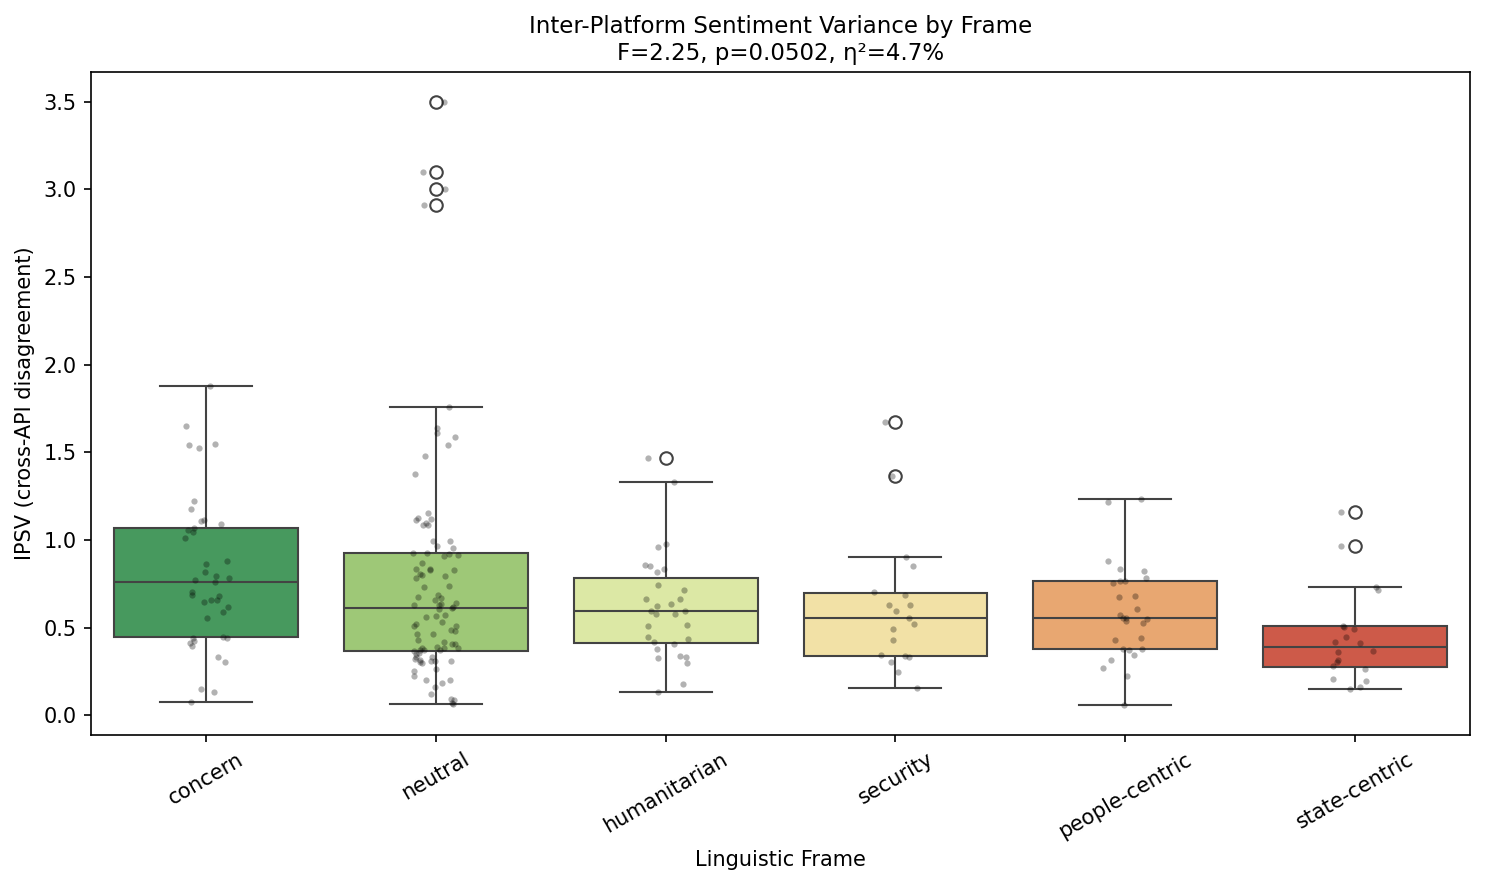

✓ Saved: boxplot_ipsv_by_frame.png + 3 CSVs


In [56]:
# cell 9b - IPSV ranked by Frame (explicit RQ3 frame-level test)
# augments the existing IPSV ~ topic + region + outlet ANOVA with
# a one-way IPSV ~ frame decomposition + Tukey HSD post-hoc.
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_ipsv = pd.read_csv('api_results/results_ipsv.csv')

# patsy/statsmodels cannot interpret pandas StringDtype; cast every
# string-dtype column to plain object right after loading.
for _c in df_ipsv.select_dtypes(include='string').columns:
    df_ipsv[_c] = df_ipsv[_c].astype('object')

# drop frames with n<5 - Tukey unreliable with tiny cells (skeptical has n=3)
frame_counts = df_ipsv['frame'].value_counts()
keep_frames = frame_counts[frame_counts >= 5].index.tolist()
df_f = df_ipsv[df_ipsv['frame'].isin(keep_frames)].copy()
df_f['frame'] = df_f['frame'].astype('object')   # patsy-safe
df_f['IPSV']  = pd.to_numeric(df_f['IPSV'], errors='coerce')
df_f = df_f.dropna(subset=['IPSV'])
print(f'Kept {len(keep_frames)} frames with n≥5 '
      f'(excluded {len(df_ipsv) - len(df_f)} articles)\n')

# descriptives, ranked by mean IPSV
desc = (df_f.groupby('frame')['IPSV']
            .agg(['mean', 'std', 'median', 'count'])
            .round(4)
            .sort_values('mean', ascending=False))
print('IPSV by frame (ranked by mean):')
print(desc.to_string())

# one-way ANOVA
model = ols('IPSV ~ C(frame)', data=df_f).fit()
anova_frame = sm.stats.anova_lm(model, typ=2)
anova_frame['eta_squared_pct'] = (
    anova_frame['sum_sq'] / anova_frame['sum_sq'].sum() * 100).round(2)
print('\nOne-way ANOVA: IPSV ~ frame')
print(anova_frame.round(4).to_string())
print(f'Model R² = {model.rsquared:.4f}')

# tukey HSD post-hoc - which frame pairs differ?
tukey = pairwise_tukeyhsd(df_f['IPSV'], df_f['frame'], alpha=0.05)
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:],
                        columns=tukey._results_table.data[0])
sig_pairs = tukey_df[tukey_df['reject'] == True]
print('\nTukey HSD post-hoc (significant pairs):')
print(sig_pairs.to_string(index=False) if len(sig_pairs)
      else '  (none significant at α=0.05)')

# save
desc.to_csv(os.path.join(OUTPUT_DIR, 'table_ipsv_by_frame.csv'))
anova_frame.to_csv(os.path.join(OUTPUT_DIR, 'table_ipsv_frame_anova.csv'))
tukey_df.to_csv(os.path.join(OUTPUT_DIR, 'table_ipsv_frame_tukey.csv'), index=False)

# boxplot
fig, ax = plt.subplots(figsize=(10, 6))
order = df_f.groupby('frame')['IPSV'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df_f, x='frame', y='IPSV', order=order,
            palette='RdYlGn_r', ax=ax)
sns.stripplot(data=df_f, x='frame', y='IPSV', order=order,
              color='black', alpha=0.3, size=3, ax=ax)
f_val = anova_frame.loc['C(frame)', 'F']
p_val = anova_frame.loc['C(frame)', 'PR(>F)']
eta = anova_frame.loc['C(frame)', 'eta_squared_pct']
ax.set_title(f'Inter-Platform Sentiment Variance by Frame\n'
             f'F={f_val:.2f}, p={p_val:.4f}, η²={eta:.1f}%', fontsize=11)
ax.set_xlabel('Linguistic Frame')
ax.set_ylabel('IPSV (cross-API disagreement)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'boxplot_ipsv_by_frame.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: boxplot_ipsv_by_frame.png + 3 CSVs')


Core PERSON/LOCATION/ORG entities after filtering: 37,664

CROSS-API NER OVERLAP — Jaccard similarity

Overall (PERSON + LOCATION + ORGANIZATION pooled):
       api_pair  mean_jaccard  median_jaccard  std_jaccard  n_articles
   AWS vs Azure        0.6051          0.6250       0.1115         237
  AWS vs Google        0.3152          0.3065       0.0780         237
Azure vs Google        0.3732          0.3587       0.0951         237

Per-type breakdown:
 entity_type        api_pair  mean_jaccard  n_articles
      PERSON    AWS vs Azure        0.6314         231
      PERSON   AWS vs Google        0.1997         233
      PERSON Azure vs Google        0.2036         231
    LOCATION    AWS vs Azure        0.4550         237
    LOCATION   AWS vs Google        0.3168         237
    LOCATION Azure vs Google        0.4941         237
ORGANIZATION    AWS vs Azure        0.4982         232
ORGANIZATION   AWS vs Google        0.2819         234
ORGANIZATION Azure vs Google        0.3132    

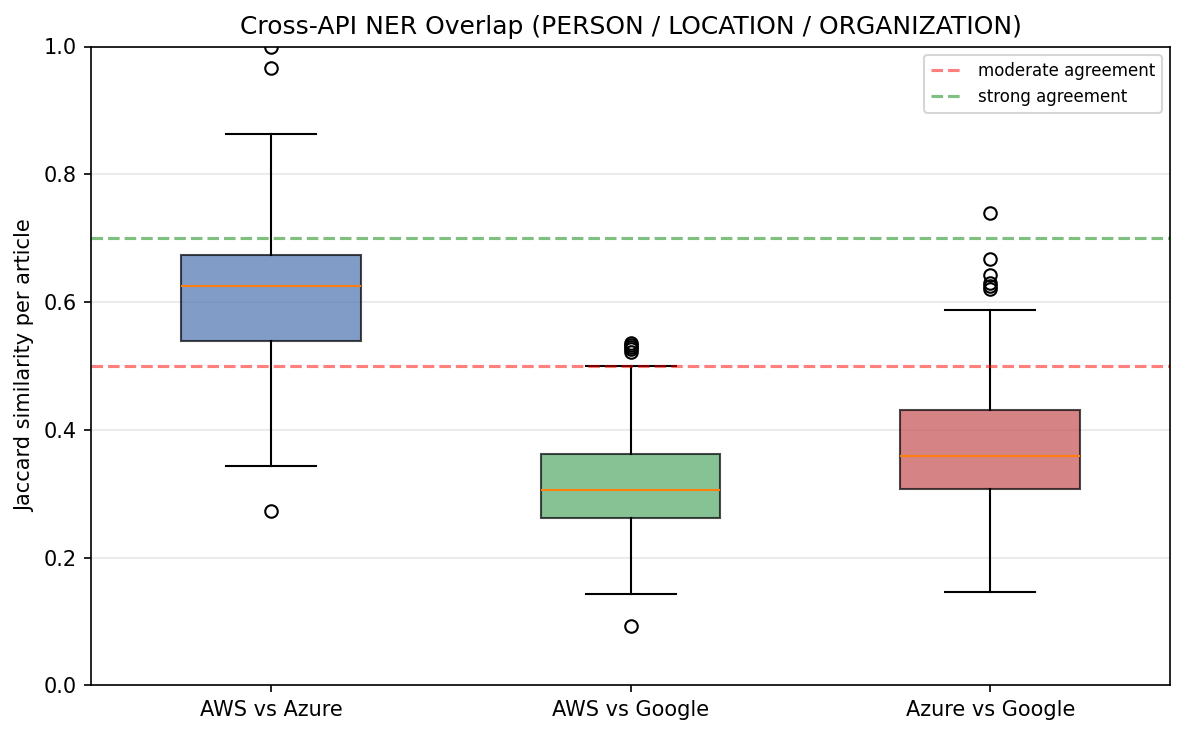


✓ Saved: boxplot_ner_jaccard.png + 3 CSVs


In [57]:
# cell - Cross-API NER overlap (Jaccard) for RQ1's NER component
# tests whether the three APIs agree on WHICH entities are present,
# complementing the IAEI metric (which is intra-article).
from itertools import combinations

ents = pd.read_csv('api_results/results_entities.csv')

# canonical type mapping (AWS/Google use UPPERCASE, Azure capitalises)
TYPE_MAP = {
    'PERSON': 'PERSON', 'Person': 'PERSON',
    'LOCATION': 'LOCATION', 'Location': 'LOCATION',
    'ORGANIZATION': 'ORGANIZATION', 'Organization': 'ORGANIZATION',
}
ents['entity_type_canonical'] = ents['entity_type'].map(TYPE_MAP)
CORE_TYPES = ['PERSON', 'LOCATION', 'ORGANIZATION']
ents_c = ents[ents['entity_type_canonical'].isin(CORE_TYPES)].copy()

# text normalisation
ents_c['entity_norm'] = (ents_c['entity_text'].astype(str)
                         .str.lower().str.strip()
                         .str.replace(r'\s+', ' ', regex=True))

# confidence filter - keep Google (no scores) + AWS/Azure ≥ 0.5
MIN_CONF = 0.5
mask = ents_c['confidence'].isna() | (ents_c['confidence'] >= MIN_CONF)
ents_c = ents_c[mask]
print(f'Core PERSON/LOCATION/ORG entities after filtering: {len(ents_c):,}\n')

def jaccard(a, b):
    union = a | b
    return len(a & b) / len(union) if union else np.nan

# per-article-per-API entity sets
sets_by = (ents_c.groupby(['article_id', 'api'])['entity_norm']
                 .apply(set).reset_index())
pivot = sets_by.pivot(index='article_id', columns='api', values='entity_norm')
apis = sorted(pivot.columns.tolist())

# overall pairwise Jaccard
print('CROSS-API NER OVERLAP — Jaccard similarity')
print('=' * 60)
pair_results, all_jacc = [], {}
for a1, a2 in combinations(apis, 2):
    pair_data = pivot[[a1, a2]].dropna()
    js = pair_data.apply(lambda r: jaccard(r[a1], r[a2]), axis=1)
    all_jacc[f'{a1} vs {a2}'] = js
    pair_results.append({
        'api_pair': f'{a1} vs {a2}',
        'mean_jaccard': round(js.mean(), 4),
        'median_jaccard': round(js.median(), 4),
        'std_jaccard': round(js.std(), 4),
        'n_articles': int(js.notna().sum()),
    })
overall = pd.DataFrame(pair_results)
print('\nOverall (PERSON + LOCATION + ORGANIZATION pooled):')
print(overall.to_string(index=False))

# per-entity-type breakdown
per_type_rows = []
for etype in CORE_TYPES:
    sub = ents_c[ents_c['entity_type_canonical'] == etype]
    sets_t = sub.groupby(['article_id', 'api'])['entity_norm'].apply(set).reset_index()
    pivot_t = sets_t.pivot(index='article_id', columns='api', values='entity_norm')
    for a1, a2 in combinations(apis, 2):
        if a1 not in pivot_t.columns or a2 not in pivot_t.columns:
            continue
        pair_data = pivot_t[[a1, a2]].dropna()
        if len(pair_data) == 0: continue
        js = pair_data.apply(lambda r: jaccard(r[a1], r[a2]), axis=1)
        per_type_rows.append({
            'entity_type': etype, 'api_pair': f'{a1} vs {a2}',
            'mean_jaccard': round(js.mean(), 4),
            'n_articles': int(js.notna().sum()),
        })
per_type_df = pd.DataFrame(per_type_rows)
print('\nPer-type breakdown:')
print(per_type_df.to_string(index=False))

# by topic
meta = ents_c[['article_id', 'topic']].drop_duplicates('article_id').set_index('article_id')
topic_rows = []
for a1, a2 in combinations(apis, 2):
    pd_pair = pivot[[a1, a2]].dropna().copy()
    pd_pair['jacc'] = pd_pair.apply(lambda r: jaccard(r[a1], r[a2]), axis=1)
    pd_pair['topic'] = pd_pair.index.map(meta['topic'])
    for topic, row in pd_pair.groupby('topic')['jacc'].agg(['mean', 'count']).iterrows():
        topic_rows.append({
            'api_pair': f'{a1} vs {a2}', 'topic': topic,
            'mean_jaccard': round(row['mean'], 4), 'n_articles': int(row['count'])
        })
topic_df = pd.DataFrame(topic_rows)
print('\nBy topic:')
print(topic_df.to_string(index=False))

# entity counts per article - shows raw labelling differences
print('\nMean entities per article by type × API:')
counts = (ents_c.groupby(['article_id', 'api', 'entity_type_canonical'])
                .size().unstack(fill_value=0).reset_index())
print(counts.groupby('api')[CORE_TYPES].mean().round(2).to_string())

# save
overall.to_csv(os.path.join(OUTPUT_DIR, 'table_ner_jaccard.csv'), index=False)
per_type_df.to_csv(os.path.join(OUTPUT_DIR, 'table_ner_jaccard_per_type.csv'), index=False)
topic_df.to_csv(os.path.join(OUTPUT_DIR, 'table_ner_jaccard_by_topic.csv'), index=False)

# boxplot
fig, ax = plt.subplots(figsize=(8, 5))
data = [all_jacc[k].dropna().values for k in all_jacc]
bp = ax.boxplot(data, positions=range(len(data)), patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], ['#4C72B0', '#55A868', '#C44E52']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(list(all_jacc.keys()))
ax.set_ylabel('Jaccard similarity per article')
ax.set_title('Cross-API NER Overlap (PERSON / LOCATION / ORGANIZATION)')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='moderate agreement')
ax.axhline(0.7, color='green', linestyle='--', alpha=0.5, label='strong agreement')
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'boxplot_ner_jaccard.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('\n✓ Saved: boxplot_ner_jaccard.png + 3 CSVs')

## Summary of Findings

Collects key statistics from all analyses into a single summary.

In [58]:
print('BIAS DECOMPOSITION — KEY FINDINGS SUMMARY')
print('=' * 65)

print(f'\n1. API-LEVEL PATTERNS')
for api in apis:
    mean = df_sent[df_sent['api'] == api]['net_sentiment'].mean()
    std = df_sent[df_sent['api'] == api]['net_sentiment'].std()
    print(f'   {api}: mean={mean:.4f}, std={std:.4f}')

print(f'\n2. VARIANCE DECOMPOSITION (from ANOVA)')
for factor in decomp.index:
    pct = decomp.loc[factor, 'eta_squared_pct']
    print(f'   {factor}: {pct:.1f}% of sentiment variance')
print(f'   Unexplained: {residual_pct:.1f}%')

print(f'\n3. TOPIC BASELINES')
for topic in sorted(df_sent['topic'].unique()):
    mean = df_sent[df_sent['topic'] == topic]['net_sentiment'].mean()
    print(f'   {topic}: mean={mean:.4f}')

print(f'\n4. INTERPRETATION GUIDE')
print('   - If API explains most variance → the APIs themselves are the main source of difference')
print('   - If topic explains most variance → sentiment differences are driven by subject matter (not bias)')
print('   - If outlet/region explains most variance → actual editorial or geographic bias is at play')
print('   - Residual = article-level variation not captured by any factor')

print(f'\n\nAll outputs saved to: {OUTPUT_DIR}/')

BIAS DECOMPOSITION — KEY FINDINGS SUMMARY

1. API-LEVEL PATTERNS
   AWS: mean=-0.0583, std=0.1148
   Azure: mean=-0.7272, std=0.2148
   Google: mean=-0.3072, std=0.1473

2. VARIANCE DECOMPOSITION (from ANOVA)
   api: 74.0% of sentiment variance
   topic: 0.8% of sentiment variance
   outlet: 2.2% of sentiment variance
   Unexplained: 23.1%

3. TOPIC BASELINES
   environment: mean=-0.3408
   immigration: mean=-0.3439
   political conflict: mean=-0.4030

4. INTERPRETATION GUIDE
   - If API explains most variance → the APIs themselves are the main source of difference
   - If topic explains most variance → sentiment differences are driven by subject matter (not bias)
   - If outlet/region explains most variance → actual editorial or geographic bias is at play
   - Residual = article-level variation not captured by any factor


All outputs saved to: analysis_results/


In [59]:
"""
IAEI Summary Statistics for Section 4.9
=========================================
Intra-Article Entity Inconsistency
section of the Results chapter.

"""

import pandas as pd
import numpy as np
from scipy import stats

# 1. LOAD DATA (uses the canonical outlet → country → region mapping
# established in Cell 4 of this notebook; do NOT duplicate
# the mapping here - that previously misclassified News24
# and Daily Maverick as Western)
iaei = pd.read_csv("api_results/results_iaei.csv")
ipsv = pd.read_csv("api_results/results_ipsv.csv")

# apply the canonical normalisation + region map (same as Cell 4)
for d in [iaei, ipsv]:
    d['outlet'] = d['outlet'].replace(OUTLET_NORMALISATION)
    d['country'] = d['outlet'].map(OUTLET_COUNTRY).fillna('Unknown')
    d['region']  = d['country'].map(COUNTRY_REGION).fillna('Unknown')

# sanity check: no Unknown rows should remain after the api_pipeline_2 fix
n_unknown = (iaei['region'] == 'Unknown').sum()
if n_unknown > 0:
    print(f'⚠ {n_unknown} IAEI rows with Unknown region — outlets: '
          f'{sorted(iaei.loc[iaei["region"] == "Unknown", "outlet"].unique())}')

print("=" * 70)
print("IAEI SUMMARY STATISTICS — FOR SECTION 4.9")
print("=" * 70)
print(f"\nTotal IAEI records: {len(iaei)}")
print(f"Unique articles: {iaei['article_id'].nunique()}")
print(f"APIs covered: {sorted(iaei['api'].unique())}")
print(f"Methods: {sorted(iaei['method'].unique())}")

# 2. OVERALL IAEI PER API (headline numbers for §4.9 ¶1)
print("\n\n[§4.9 ¶1] IAEI descriptive statistics by API")
print("-" * 70)
per_api = iaei.groupby("api")["IAEI"].describe().round(4)
print(per_api.to_string())

# 3. IAEI PER TOPIC PER API (to test whether specific domains drive IAEI)
print("\n\n[§4.9 ¶2] IAEI by topic × API (mean ± std)")
print("-" * 70)
by_topic = iaei.groupby(["api", "topic"])["IAEI"].agg(
    ["count", "mean", "std", "median"]
).round(4)
print(by_topic.to_string())

# 4. IAEI PER FRAME PER API
print("\n\n[§4.9 ¶2] IAEI by frame × API (mean)")
print("-" * 70)
by_frame = iaei.groupby(["api", "frame"])["IAEI"].agg(
    ["count", "mean", "std"]
).round(4)
print(by_frame.to_string())

# 5. IAEI BY REGION
print("\n\n[§4.9 ¶3] IAEI by region × API (Western vs Non-Western)")
print("-" * 70)
by_region = iaei.groupby(["api", "region"])["IAEI"].agg(
    ["count", "mean", "std"]
).round(4)
print(by_region.to_string())

print("\nWelch's t-test: Western vs Non-Western IAEI, per API")
print("-" * 70)
for api in sorted(iaei["api"].unique()):
    sub = iaei[iaei["api"] == api]
    w = sub[sub["region"] == "Western"]["IAEI"].dropna()
    n = sub[sub["region"] == "Non-Western"]["IAEI"].dropna()
    if len(w) > 1 and len(n) > 1:
        t, p = stats.ttest_ind(w, n, equal_var=False)
        pooled_std = np.sqrt((w.var() + n.var()) / 2)
        d = (w.mean() - n.mean()) / pooled_std if pooled_std else np.nan
        print(f"  {api:8s}  t = {t:+.3f}  p = {p:.4f}  "
              f"d = {d:+.3f}  (W n={len(w)}, NW n={len(n)})")

# 6. RELATIONSHIP BETWEEN IAEI AND IPSV
print("\n\n[§4.9 ¶4] Correlation between per-article IAEI and IPSV")
print("-" * 70)
iaei_per_article = iaei.groupby("article_id")["IAEI"].mean().reset_index()
iaei_per_article.columns = ["article_id", "IAEI_mean"]

merged = ipsv[["article_id", "IPSV"]].merge(iaei_per_article, on="article_id")
r, p = stats.pearsonr(merged["IAEI_mean"], merged["IPSV"])
print(f"  Pearson r = {r:+.4f}  p = {p:.4f}  n = {len(merged)}")

print("\nPer-API Pearson r (IAEI vs IPSV):")
for api in sorted(iaei["api"].unique()):
    api_iaei = iaei[iaei["api"] == api][["article_id", "IAEI"]]
    m = ipsv[["article_id", "IPSV"]].merge(api_iaei, on="article_id")
    if len(m) > 3:
        r, p = stats.pearsonr(m["IAEI"], m["IPSV"])
        print(f"  {api:8s}  r = {r:+.4f}  p = {p:.4f}  n = {len(m)}")

# 7. TOP 5 HIGHEST-IAEI ARTICLES PER API (qualitative illustration)
print("\n\n[§4.9 optional] Top 5 articles with highest IAEI per API")
print("-" * 70)
for api in sorted(iaei["api"].unique()):
    print(f"\n  {api}:")
    top = iaei[iaei["api"] == api].nlargest(5, "IAEI")[
        ["article_id", "outlet", "topic", "frame", "IAEI"]
    ]
    print(top.to_string(index=False))

# 8. ONE-WAY ANOVA on IAEI across APIs
# (a significant F is EXPECTED - different operationalisations)
print("\n\n[§4.9 caveat] One-way ANOVA on IAEI across APIs")
print("-" * 70)
groups = [iaei[iaei["api"] == a]["IAEI"].dropna() for a in sorted(iaei["api"].unique())]
f_stat, p_val = stats.f_oneway(*groups)
print(f"  F = {f_stat:.3f}  p = {p_val:.4g}")
print("  Interpretation: a significant F here is EXPECTED and does not")
print("  indicate bias — it reflects the native-vs-projection")
print("  operationalisation difference. Interpret IAEI comparisons *within*")
print("  each method only.")

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)


IAEI SUMMARY STATISTICS — FOR SECTION 4.9

Total IAEI records: 679
Unique articles: 237
APIs covered: ['AWS', 'Azure', 'Google']
Methods: ['native_entity_sentiment', 'sentence_context_projection']


[§4.9 ¶1] IAEI descriptive statistics by API
----------------------------------------------------------------------
        count    mean     std     min     25%     50%     75%     max
api                                                                  
AWS     236.0  0.1006  0.0775  0.0073  0.0526  0.0792  0.1222  0.5710
Azure   206.0  0.3902  0.1812  0.0214  0.2580  0.3801  0.4888  1.3933
Google  237.0  0.2931  0.1306  0.0000  0.2016  0.2862  0.3743  0.7000


[§4.9 ¶2] IAEI by topic × API (mean ± std)
----------------------------------------------------------------------
                           count    mean     std  median
api    topic                                            
AWS    environment            63  0.1427  0.1149  0.1062
       immigration            88  0.0874  0.0529

## Key Phrase Audit (Framing Sensitivity & Loaded Vocabulary)

This cell extends the audit to the third API function: **key phrase extraction**.
Two complementary analyses are run:

* **Cell 11a (Option B):** Framing sensitivity at the key-phrase level. For
  each event, key-phrase set Jaccard is computed for (i) within-event,
  cross-frame article pairs, (ii) within-event, within-frame pairs (baseline),
  and (iii) across-event pairs (negative control). A mixed-effects model
  with `event_id` as random factor tests whether cross-frame Jaccard is
  significantly lower than within-frame Jaccard - i.e. whether different
  framings of the same event surface systematically different phrases.

* **Cell 11b (Option C):** Loaded-vocabulary surfacing. Phrases are matched
  against the LFI frame lexicons (lemmatised, token-level), and the
  *loaded-phrase ratio* (loaded hits / total phrases) is reported per
  outlet × topic × API. The ratio is also correlated with the article's
  LFI score to test whether key-phrase extractors amplify the same framing
  signal the LFI metric measures structurally.

**Methodological note on Google.** Google Cloud Natural Language does not
expose a key-phrase endpoint; the audit proxies key phrases as the top-15
salience entities (set in `api_pipeline_2`). This is a heterogeneous
operationalisation relative to AWS and Azure (which return phrasal
constructions), and Google is therefore reported alongside AWS / Azure
with this caveat made explicit. The cross-API comparison is informative
even when not strictly equivalent: divergence between Google and the other
two is itself a finding about platform heterogeneity in what "salient
content" means.

Loaded 65,224 key-phrase rows across 237 articles × 3 APIs
api
AWS       37197
Azure     24472
Google     3555

Within-event pairs: 1308 (cross-frame=778, within-frame=530)
Across-event pairs (same-topic, sampled): 1308

── Mean key-phrase Jaccard per API × pair type ──
                       mean  median     std  count
api    pair_type                                  
AWS    across_event  0.0198  0.0143  0.0196   1308
       cross_frame   0.0758  0.0660  0.0508    778
       within_frame  0.0751  0.0612  0.0679    530
Azure  across_event  0.0152  0.0110  0.0160   1308
       cross_frame   0.0600  0.0490  0.0545    778
       within_frame  0.0605  0.0456  0.0746    530
Google across_event  0.0274  0.0000  0.0510   1308
       cross_frame   0.1327  0.1200  0.0857    778
       within_frame  0.1362  0.1200  0.0942    530

── Mixed-effects test: cross_frame vs within_frame Jaccard ──
   AWS     Δ(cross−within) = -0.0060  p = 0.0405  d = +0.012 (negligible) *  [mixedlm]
   Azure   Δ(cross

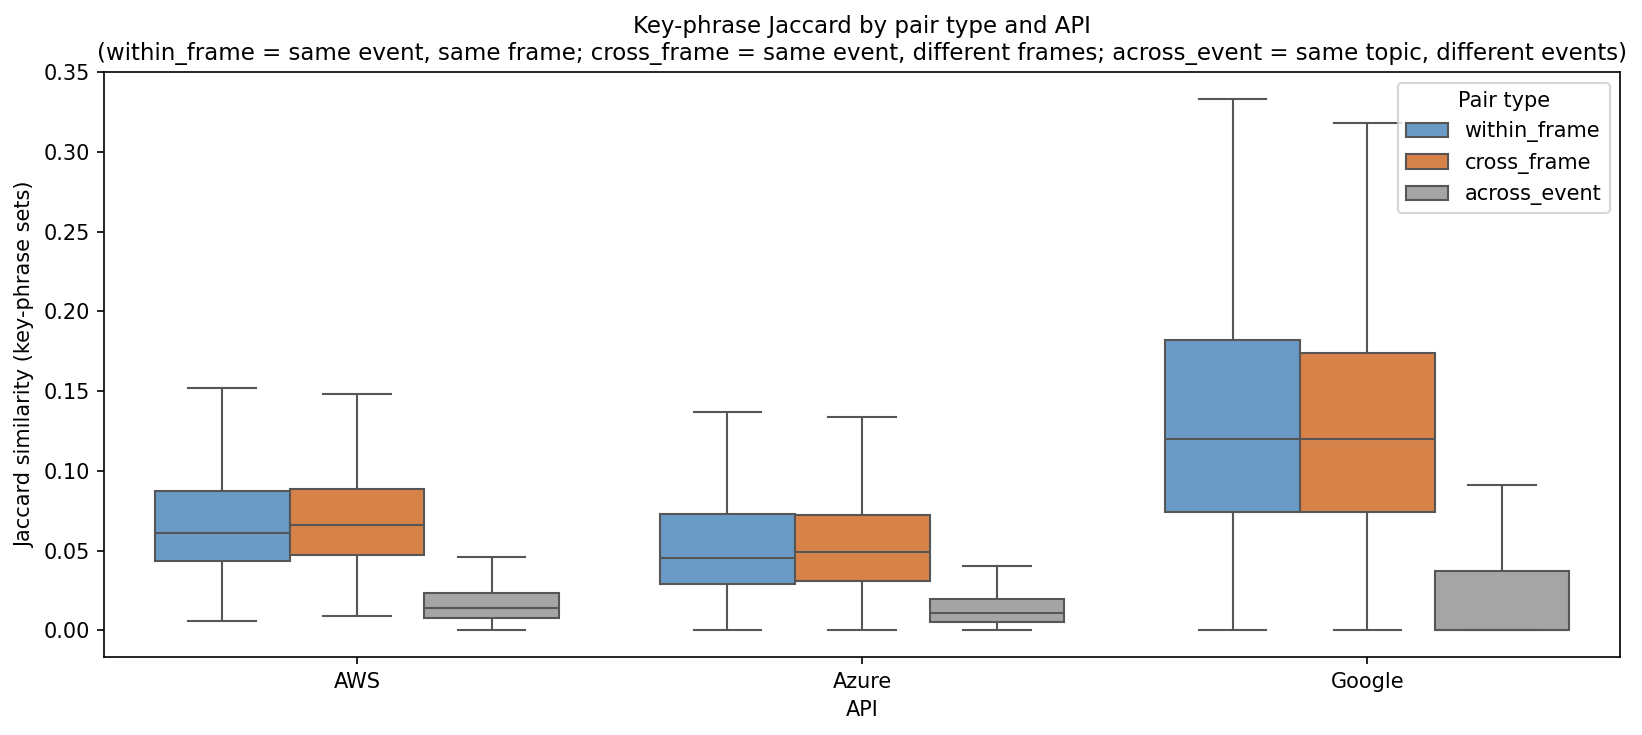

✓ Saved: boxplot_keyphrase_jaccard_framing.png


In [60]:
# cell 11a - Option B: Key-Phrase Framing Sensitivity
import pandas as pd
import numpy as np
import re
from itertools import combinations
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

try:
    import statsmodels.formula.api as smf
    _HAS_SM = True
except Exception:
    _HAS_SM = False

# ── Load key phrases ──────────────────────────────────────────────────
df_kp = pd.read_csv('api_results/results_keyphrases.csv')
df_kp = df_kp.dropna(subset=['phrase', 'article_id', 'api'])
print(f'Loaded {len(df_kp):,} key-phrase rows across '
      f'{df_kp["article_id"].nunique()} articles × '
      f'{df_kp["api"].nunique()} APIs')
print(df_kp.groupby('api').size().to_string())

# ── Phrase normalisation ──────────────────────────────────────────────
# AWS returns determiners ("the arrest"), Azure / Google do not.
# lowercase, strip leading determiners + possessives, collapse whitespace.
_LEAD_DET = re.compile(r'^(the|a|an|this|that|these|those|my|your|his|her|its|our|their)\s+')

def normalise_phrase(p):
    if not isinstance(p, str):
        return ''
    s = p.strip().lower()
    s = _LEAD_DET.sub('', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df_kp['phrase_norm'] = df_kp['phrase'].map(normalise_phrase)
df_kp = df_kp[df_kp['phrase_norm'].str.len() > 1]

# ── Per-(article, API) phrase sets ────────────────────────────────────
phrase_sets = (df_kp.groupby(['article_id', 'api'])['phrase_norm']
                    .agg(lambda s: frozenset(s))
                    .reset_index())
phrase_set_lookup = {(r.article_id, r.api): r.phrase_norm
                     for r in phrase_sets.itertuples()}

# article metadata
meta_cols = ['article_id', 'pair_id', 'outlet', 'topic', 'frame']
df_meta = df_kp[meta_cols].drop_duplicates().set_index('article_id')

def jaccard(a, b):
    if not a or not b:
        return np.nan
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union else np.nan

# ── Build pair-level dataframe ────────────────────────────────────────
# pair_id in this corpus is the EVENT cluster (10-14 articles, 2-3 frames).
# following the FDI design, three pair types:
# (1) within-event, cross-frame - high framing contrast
# (2) within-event, within-frame - baseline (same event, same frame)
# (3) across-event - negative control (different topic)
APIS = ['AWS', 'Azure', 'Google']

# (1) + (2): within-event pairs
within_rows = []
for event_id, sub in df_meta.groupby('pair_id'):
    arts = sub.index.tolist()
    for a1, a2 in combinations(arts, 2):
        f1, f2 = sub.loc[a1, 'frame'], sub.loc[a2, 'frame']
        pair_type = 'cross_frame' if f1 != f2 else 'within_frame'
        topic = sub.loc[a1, 'topic']
        row = {'event_id': event_id, 'article_id_1': a1, 'article_id_2': a2,
               'frame_1': f1, 'frame_2': f2, 'topic': topic,
               'pair_type': pair_type}
        for api in APIS:
            s1 = phrase_set_lookup.get((a1, api), frozenset())
            s2 = phrase_set_lookup.get((a2, api), frozenset())
            row[f'jaccard_{api}'] = jaccard(s1, s2)
        within_rows.append(row)
df_within = pd.DataFrame(within_rows)
print(f'\nWithin-event pairs: {len(df_within)} '
      f'(cross-frame={(df_within["pair_type"]=="cross_frame").sum()}, '
      f'within-frame={(df_within["pair_type"]=="within_frame").sum()})')

# (3) across-event: random sample matched in size to within-event pairs,
# same-topic only (controls for topic vocabulary)
rng = np.random.default_rng(31279279)
across_rows = []
n_target = len(df_within)
all_articles_by_topic = df_meta.groupby('topic').apply(
    lambda s: s.index.tolist(), include_groups=False
).to_dict()
event_of_article = df_meta['pair_id'].to_dict()

tries = 0
while len(across_rows) < n_target and tries < n_target * 50:
    tries += 1
    topic = rng.choice(list(all_articles_by_topic.keys()))
    pool = all_articles_by_topic[topic]
    a1, a2 = rng.choice(pool, size=2, replace=False)
    if event_of_article[a1] == event_of_article[a2]:
        continue  # must be different events
    row = {'event_id_1': event_of_article[a1],
           'event_id_2': event_of_article[a2],
           'article_id_1': a1, 'article_id_2': a2,
           'frame_1': df_meta.loc[a1, 'frame'],
           'frame_2': df_meta.loc[a2, 'frame'],
           'topic': topic, 'pair_type': 'across_event'}
    for api in APIS:
        s1 = phrase_set_lookup.get((a1, api), frozenset())
        s2 = phrase_set_lookup.get((a2, api), frozenset())
        row[f'jaccard_{api}'] = jaccard(s1, s2)
    across_rows.append(row)
df_across = pd.DataFrame(across_rows)
print(f'Across-event pairs (same-topic, sampled): {len(df_across)}')

# ── Combine for analysis ──────────────────────────────────────────────
df_within['__src'] = 'within_event'
df_across['__src'] = 'across_event'
df_pairs = pd.concat([df_within.assign(event_id_for_re=df_within['event_id']),
                      df_across.assign(event_id_for_re=df_across['event_id_1'])],
                     ignore_index=True, sort=False)

# long form for plotting
long_rows = []
for api in APIS:
    sub = df_pairs[['pair_type', 'topic', 'event_id_for_re',
                    f'jaccard_{api}']].copy()
    sub = sub.rename(columns={f'jaccard_{api}': 'jaccard'})
    sub['api'] = api
    long_rows.append(sub)
df_long = pd.concat(long_rows, ignore_index=True).dropna(subset=['jaccard'])

print('\n── Mean key-phrase Jaccard per API × pair type ──')
summary = (df_long.groupby(['api', 'pair_type'])['jaccard']
                  .agg(['mean', 'median', 'std', 'count'])
                  .round(4))
print(summary.to_string())

# ── Statistical test: cross-frame vs within-frame (within-event only) ─
# mixed-effects model with event_id as random factor.
# if statsmodels unavailable, fall back to paired-by-event Welch t-test.
print('\n── Mixed-effects test: cross_frame vs within_frame Jaccard ──')
test_rows = []
for api in APIS:
    sub = df_long[(df_long['api'] == api) &
                  (df_long['pair_type'].isin(['cross_frame', 'within_frame']))].copy()
    sub['is_cross'] = (sub['pair_type'] == 'cross_frame').astype(int)
    if _HAS_SM and sub['event_id_for_re'].nunique() > 1:
        try:
            model = smf.mixedlm('jaccard ~ is_cross', sub,
                                groups=sub['event_id_for_re']).fit(
                                    method='lbfgs', disp=False)
            coef = float(model.params['is_cross'])
            se   = float(model.bse['is_cross'])
            z    = coef / se if se else np.nan
            p    = float(model.pvalues['is_cross'])
            test = 'mixedlm'
        except Exception as ex:
            print(f'   {api}: mixedlm failed ({ex}); falling back to t-test')
            cross  = sub.loc[sub['is_cross'] == 1, 'jaccard']
            within = sub.loc[sub['is_cross'] == 0, 'jaccard']
            t, p = stats.ttest_ind(cross, within, equal_var=False)
            coef = cross.mean() - within.mean(); se = np.nan; z = t
            test = 'welch_t'
    else:
        cross  = sub.loc[sub['is_cross'] == 1, 'jaccard']
        within = sub.loc[sub['is_cross'] == 0, 'jaccard']
        t, p = stats.ttest_ind(cross, within, equal_var=False)
        coef = cross.mean() - within.mean(); se = np.nan; z = t
        test = 'welch_t'

    # cohen's d on the raw (unclustered) values
    cross  = sub.loc[sub['is_cross'] == 1, 'jaccard']
    within = sub.loc[sub['is_cross'] == 0, 'jaccard']
    pooled_sd = np.sqrt(((cross.var(ddof=1) * (len(cross)-1)) +
                         (within.var(ddof=1) * (len(within)-1))) /
                        (len(cross) + len(within) - 2))
    d = (cross.mean() - within.mean()) / pooled_sd if pooled_sd else np.nan
    eff = 'large' if abs(d) >= .8 else 'medium' if abs(d) >= .5 \
         else 'small' if abs(d) >= .2 else 'negligible'
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'
    print(f'   {api:6s}  Δ(cross−within) = {coef:+.4f}  '
          f'p = {p:.4f}  d = {d:+.3f} ({eff}) {sig}  [{test}]')
    test_rows.append({
        'api': api, 'mean_cross_frame': cross.mean(),
        'mean_within_frame': within.mean(),
        'mean_across_event': df_long[(df_long.api == api) &
                                     (df_long.pair_type == 'across_event')]
                                     ['jaccard'].mean(),
        'delta_cross_minus_within': coef, 'se': se, 'z_or_t': z, 'p_value': p,
        'cohens_d': d, 'effect_size': eff, 'significance': sig,
        'test_type': test,
        'n_cross_frame': int((sub['is_cross']==1).sum()),
        'n_within_frame': int((sub['is_cross']==0).sum()),
    })

# benjamini-Hochberg FDR correction across the 3 APIs
test_df = pd.DataFrame(test_rows).sort_values('p_value').reset_index(drop=True)
m = len(test_df)
test_df['p_value_fdr'] = (test_df['p_value'] * m /
                          (test_df.index + 1)).clip(upper=1.0)
test_df = test_df.sort_values('api').reset_index(drop=True)
test_df['sig_after_fdr'] = test_df['p_value_fdr'] < .05

# ── Save tables ───────────────────────────────────────────────────────
df_long.to_csv('table_keyphrase_jaccard_pairs.csv', index=False)
summary_out = (df_long.groupby(['api', 'pair_type'])['jaccard']
                       .agg(mean_jaccard='mean', median_jaccard='median',
                            std_jaccard='std', n_pairs='count')
                       .round(4).reset_index())
summary_out.to_csv('table_keyphrase_jaccard_summary.csv', index=False)
test_df.to_csv('table_keyphrase_framing_tests.csv', index=False)
print('\n✓ Saved: table_keyphrase_jaccard_summary.csv, '
      'table_keyphrase_framing_tests.csv, table_keyphrase_jaccard_pairs.csv')

# ── Plot: boxplot of Jaccard by pair type, faceted by API ─────────────
plt.figure(figsize=(11, 5))
order = ['within_frame', 'cross_frame', 'across_event']
palette = {'within_frame': '#5b9bd5',
           'cross_frame':  '#ed7d31',
           'across_event': '#a5a5a5'}
ax = sns.boxplot(data=df_long, x='api', y='jaccard', hue='pair_type',
                 order=APIS, hue_order=order, palette=palette,
                 showfliers=False)
ax.set_title('Key-phrase Jaccard by pair type and API\n'
             '(within_frame = same event, same frame; '
             'cross_frame = same event, different frames; '
             'across_event = same topic, different events)', fontsize=11)
ax.set_xlabel('API')
ax.set_ylabel('Jaccard similarity (key-phrase sets)')
ax.legend(title='Pair type', loc='upper right')
plt.tight_layout()
plt.savefig('boxplot_keyphrase_jaccard_framing.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('✓ Saved: boxplot_keyphrase_jaccard_framing.png')


### Loaded-Vocabulary Surfacing (Option C)

Lemmatising 25,858 unique phrases (this can take ~30–60 s)...

── Mean loaded-phrase ratio per API ──
          mean  median     std  count
api                                  
AWS     0.0395  0.0357  0.0273    237
Azure   0.0411  0.0367  0.0251    237
Google  0.0394  0.0000  0.0584    237

── Mean loaded-phrase ratio per API × topic ──
                             mean  count
api    topic                            
AWS    environment         0.0249     64
       immigration         0.0504     88
       political conflict  0.0390     85
Azure  environment         0.0298     64
       immigration         0.0485     88
       political conflict  0.0420     85
Google environment         0.0208     64
       immigration         0.0500     88
       political conflict  0.0424     85


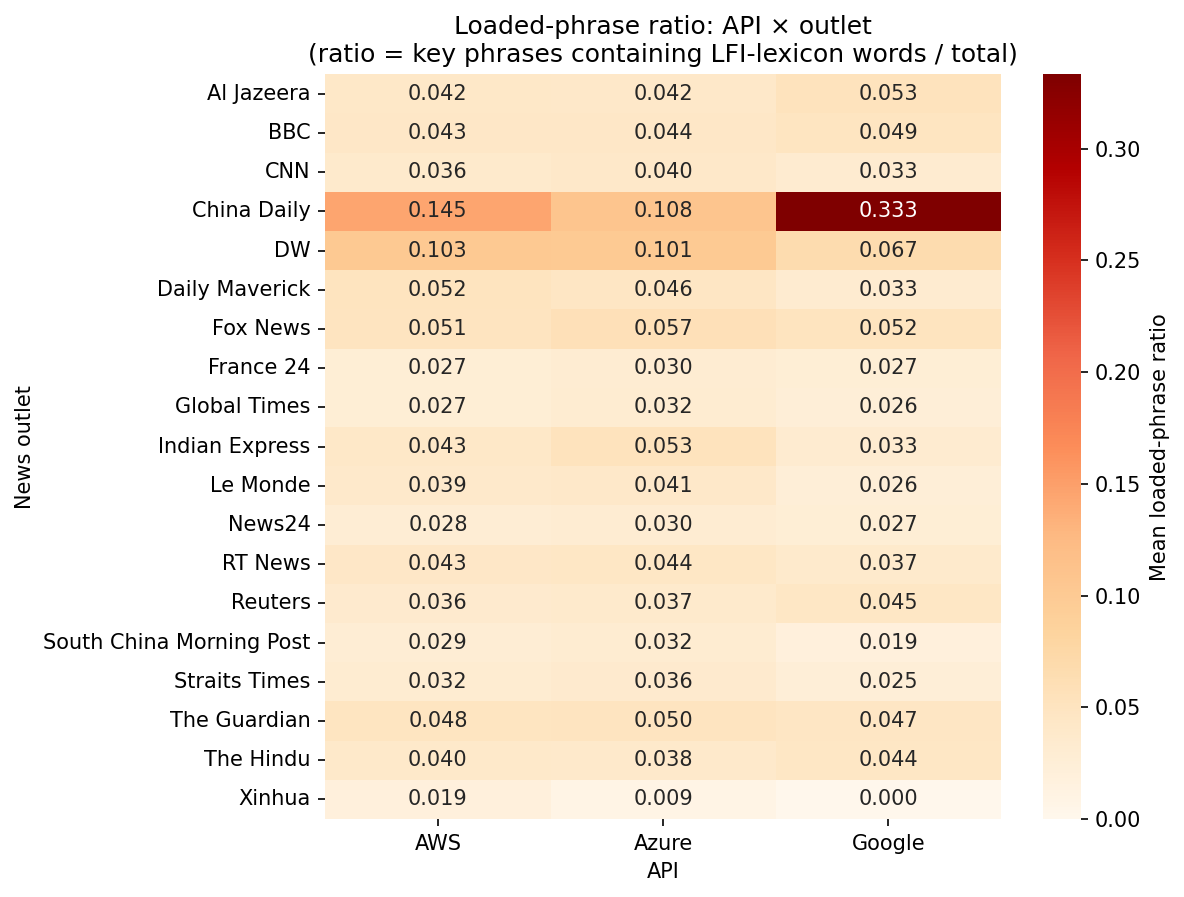

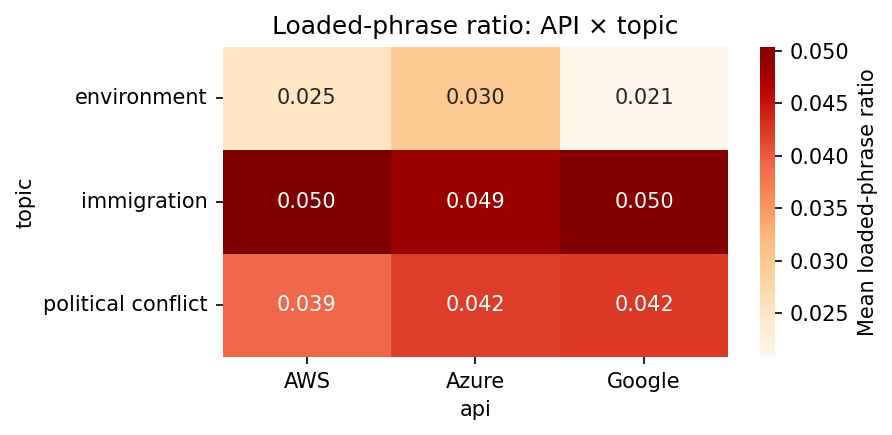


── Correlation: loaded_ratio (key phrases) vs |LFI| (structural) ──
(strong positive r ⇒ extractor amplifies same framing signal)
   AWS     Pearson r = +0.118 (p = 0.0694)  | Spearman ρ = +0.022 (p = 0.7375)  n = 237
   Azure   Pearson r = +0.067 (p = 0.3033)  | Spearman ρ = -0.012 (p = 0.8537)  n = 237
   Google  Pearson r = +0.116 (p = 0.0749)  | Spearman ρ = +0.083 (p = 0.2038)  n = 237

✓ Saved: table_keyphrase_loaded_per_article.csv, table_keyphrase_loaded_outlet_api.csv, table_keyphrase_loaded_topic_api.csv, table_keyphrase_loaded_vs_lfi_corr.csv
✓ Saved: heatmap_keyphrase_loaded_outlet.png, heatmap_keyphrase_loaded_topic.png


In [61]:
# cell 11b - Option C: Loaded-Vocabulary Surfacing in Key Phrases
# for each (article, API), compute:
# loaded_ratio = #phrases that contain at least one lemmatised token
# matching the LFI lexicon
# / total #phrases
# then test:
# (i) Per-outlet × topic ratios (heatmap)
# (ii) Correlation of per-article loaded_ratio with LFI score
# - does the key-phrase extractor amplify the same framing signal
# the LFI measures structurally?
import pandas as pd, numpy as np, re
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# ── Lazy spaCy load for lemmatisation ─────────────────────────────────
try:
    import spacy
    try:
        _NLP = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    except OSError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'spacy', 'download',
                        'en_core_web_sm', '--quiet'], check=True)
        _NLP = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    _HAS_SPACY = True
except Exception as ex:
    print(f'spaCy unavailable ({ex}); falling back to whitespace tokens '
          f'+ trailing-s stripping')
    _HAS_SPACY = False
    _NLP = None

# ── LFI lexicon (copied from api_pipeline_2 / mitigation pipeline) ────
FRAME_LEXICONS_RAW = {
    'immigration': {
        'humanitarian': [
            'refugee', 'asylum seeker', 'asylum', 'displaced', 'flee',
            'persecution', 'human rights', 'humanitarian', 'families',
            'children', 'vulnerable', 'protection', 'shelter', 'aid',
            'crisis', 'desperate', 'seeking safety', 'undocumented',
            'migrant workers', 'dream', 'opportunity', 'integration'
        ],
        'security': [
            'illegal', 'illegals', 'alien', 'invasion', 'border security',
            'enforcement', 'deportation', 'deport', 'criminal', 'gang',
            'smuggling', 'trafficking', 'threat', 'surge', 'flood',
            'overwhelm', 'overrun', 'national security', 'crackdown',
            'raid', 'detain', 'arrest', 'trespass', 'lawbreaker'
        ]
    },
    'environment': {  # mapped from 'climate_change' in lexicon code
        'concern': [
            'crisis', 'emergency', 'catastrophe', 'disaster', 'extinction',
            'irreversible', 'tipping point', 'devastating', 'urgent',
            'scientists warn', 'unprecedented', 'accelerating', 'threat',
            'carbon emissions', 'fossil fuels', 'greenhouse', 'pollution',
            'warming', 'rising sea levels', 'extreme weather', 'biodiversity',
            'ecosystem', 'sustainability', 'renewable', 'clean energy'
        ],
        'skeptical': [
            'alarmist', 'hoax', 'natural cycle', 'exaggerated', 'costly',
            'regulation', 'economic impact', 'job losses', 'burden',
            'overreach', 'uncertain', 'debate', 'models', 'prediction',
            'agenda', 'ideology', 'taxpayer'
        ]
    },
    'political conflict': {
        'people_centric': [
            'protesters', 'demonstrators', 'activists', 'peaceful',
            'movement', 'grassroots', 'civil rights', 'freedom fighters',
            'liberation', 'resistance', 'solidarity', 'uprising',
            'civilians', 'victims', 'displaced', 'suffering',
            'human rights', 'oppression', 'persecution', 'atrocities',
            'massacre', 'brutality', 'injustice', 'freedom',
            'self-determination', 'occupied', 'besieged'
        ],
        'state_centric': [
            'terrorists', 'insurgents', 'militants', 'extremists',
            'rioters', 'agitators', 'separatists', 'radicals',
            'aggression', 'provocation', 'destabilise', 'subversion',
            'national security', 'sovereignty', 'territorial integrity',
            'law and order', 'counterterrorism', 'crackdown',
            'retaliation', 'deterrence', 'regime change', 'threat',
            'hostile', 'illegal', 'incitement', 'propaganda'
        ]
    }
}

def _lemmatise_token(tok):
    if _HAS_SPACY:
        d = _NLP(tok)
        return ' '.join(t.lemma_.lower() for t in d if not t.is_space)
    # fallback: strip trailing s/es/ies for simple plurals
    s = tok.lower()
    for suf in ('ies', 'es', 's'):
        if len(s) > len(suf) + 2 and s.endswith(suf):
            return s[:-len(suf)]
    return s

# pre-lemmatise the lexicon to lemma sets, by topic and by side
LEXICON_LEMMAS = {}  # topic -> {'side': set(lemma_phrases)}
for topic, sides in FRAME_LEXICONS_RAW.items():
    LEXICON_LEMMAS[topic] = {}
    for side, words in sides.items():
        LEXICON_LEMMAS[topic][side] = set(
            _lemmatise_token(w) for w in words
        )

# combined per-topic set for the "any-loaded" ratio
LEXICON_LEMMAS_ALL = {t: set().union(*sides.values())
                      for t, sides in LEXICON_LEMMAS.items()}

# ── Lemmatise extracted phrases (cached per unique phrase) ────────────
df_kp = pd.read_csv('api_results/results_keyphrases.csv').dropna(subset=['phrase'])
df_kp['phrase'] = df_kp['phrase'].astype(str)
unique_phrases = df_kp['phrase'].drop_duplicates().tolist()
print(f'Lemmatising {len(unique_phrases):,} unique phrases '
      f'(this can take ~30–60 s)...')

if _HAS_SPACY:
    lemma_cache = {}
    for doc, phrase in zip(_NLP.pipe(unique_phrases, batch_size=200),
                            unique_phrases):
        lemma_cache[phrase] = set(t.lemma_.lower() for t in doc
                                  if t.is_alpha and not t.is_stop)
else:
    lemma_cache = {p: {_lemmatise_token(tok) for tok in re.findall(r'\w+', p)
                       if len(tok) > 1}
                   for p in unique_phrases}

df_kp['phrase_lemmas'] = df_kp['phrase'].map(lemma_cache)

# ── Per-phrase loaded flag (any overlap with that article's topic lexicon) ─
def phrase_is_loaded(phrase_lemmas, topic):
    lex = LEXICON_LEMMAS_ALL.get(topic, set())
    if not lex or not phrase_lemmas:
        return False
    # match single-token lemmas; for multi-word lexicon entries, require
    # all lemma tokens to be present in the phrase.
    for entry in lex:
        entry_toks = set(entry.split())
        if entry_toks.issubset(phrase_lemmas):
            return True
    return False

df_kp['is_loaded'] = df_kp.apply(
    lambda r: phrase_is_loaded(r['phrase_lemmas'], r['topic']),
    axis=1)

# also tag which side of the frame each loaded hit sits on
def phrase_side(phrase_lemmas, topic):
    if topic not in LEXICON_LEMMAS:
        return None
    for side, lex in LEXICON_LEMMAS[topic].items():
        for entry in lex:
            if set(entry.split()).issubset(phrase_lemmas):
                return side
    return None

df_kp['loaded_side'] = df_kp.apply(
    lambda r: phrase_side(r['phrase_lemmas'], r['topic'])
    if r['is_loaded'] else None, axis=1)

# ── Per-(article, API) loaded ratio ───────────────────────────────────
article_api_stats = (df_kp.groupby(['article_id', 'api', 'outlet', 'topic',
                                    'frame'])
                          .agg(n_phrases=('phrase', 'size'),
                               n_loaded=('is_loaded', 'sum'))
                          .reset_index())
article_api_stats['loaded_ratio'] = (article_api_stats['n_loaded'] /
                                     article_api_stats['n_phrases']
                                     .replace(0, np.nan))

print(f'\n── Mean loaded-phrase ratio per API ──')
print(article_api_stats.groupby('api')['loaded_ratio']
      .agg(['mean', 'median', 'std', 'count']).round(4).to_string())

print(f'\n── Mean loaded-phrase ratio per API × topic ──')
print(article_api_stats.groupby(['api', 'topic'])['loaded_ratio']
      .agg(['mean', 'count']).round(4).to_string())

# ── Outlet × API heatmap ──────────────────────────────────────────────
outlet_api = (article_api_stats.groupby(['outlet', 'api'])['loaded_ratio']
                                .mean().unstack('api').round(4))
plt.figure(figsize=(8, max(6, 0.32 * len(outlet_api))))
sns.heatmap(outlet_api, annot=True, fmt='.3f', cmap='OrRd',
            cbar_kws={'label': 'Mean loaded-phrase ratio'})
plt.title('Loaded-phrase ratio: API × outlet\n'
          '(ratio = key phrases containing LFI-lexicon words / total)')
plt.xlabel('API'); plt.ylabel('News outlet')
plt.tight_layout()
plt.savefig('heatmap_keyphrase_loaded_outlet.png', dpi=150,
            bbox_inches='tight')
plt.show()

# ── Topic × API heatmap ───────────────────────────────────────────────
topic_api = (article_api_stats.groupby(['topic', 'api'])['loaded_ratio']
                              .mean().unstack('api').round(4))
plt.figure(figsize=(6, 3))
sns.heatmap(topic_api, annot=True, fmt='.3f', cmap='OrRd',
            cbar_kws={'label': 'Mean loaded-phrase ratio'})
plt.title('Loaded-phrase ratio: API × topic')
plt.tight_layout()
plt.savefig('heatmap_keyphrase_loaded_topic.png', dpi=150,
            bbox_inches='tight')
plt.show()

# ── Correlation with structural LFI score ─────────────────────────────
df_lfi = pd.read_csv('api_results/results_lfi.csv')[['article_id', 'lfi_score']]
merged = article_api_stats.merge(df_lfi, on='article_id', how='left')

print('\n── Correlation: loaded_ratio (key phrases) vs |LFI| (structural) ──')
print('(strong positive r ⇒ extractor amplifies same framing signal)')
corr_rows = []
for api in ['AWS', 'Azure', 'Google']:
    sub = merged[(merged['api'] == api) &
                 merged['loaded_ratio'].notna() &
                 merged['lfi_score'].notna()].copy()
    sub['abs_lfi'] = sub['lfi_score'].abs()
    if len(sub) < 5:
        continue
    r_pearson, p_pearson = stats.pearsonr(sub['loaded_ratio'], sub['abs_lfi'])
    r_spear,   p_spear   = stats.spearmanr(sub['loaded_ratio'], sub['abs_lfi'])
    print(f'   {api:6s}  Pearson r = {r_pearson:+.3f} (p = {p_pearson:.4f}) '
          f' | Spearman ρ = {r_spear:+.3f} (p = {p_spear:.4f})  n = {len(sub)}')
    corr_rows.append({'api': api, 'pearson_r': r_pearson, 'pearson_p': p_pearson,
                      'spearman_rho': r_spear, 'spearman_p': p_spear,
                      'n': len(sub)})

# ── Save tables ───────────────────────────────────────────────────────
article_api_stats.to_csv('table_keyphrase_loaded_per_article.csv', index=False)
outlet_api.to_csv('table_keyphrase_loaded_outlet_api.csv')
topic_api.to_csv('table_keyphrase_loaded_topic_api.csv')
pd.DataFrame(corr_rows).to_csv('table_keyphrase_loaded_vs_lfi_corr.csv',
                                index=False)
print('\n✓ Saved: table_keyphrase_loaded_per_article.csv, '
      'table_keyphrase_loaded_outlet_api.csv, '
      'table_keyphrase_loaded_topic_api.csv, '
      'table_keyphrase_loaded_vs_lfi_corr.csv')
print('✓ Saved: heatmap_keyphrase_loaded_outlet.png, '
      'heatmap_keyphrase_loaded_topic.png')
